In [1]:
import os
import glob

from enum import Enum, auto

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

|   rep    | frame | current | density |
|----------|-------|---------|---------|
| 36.rep   |  9548 |     153 |  671.80 |
| 212.rep  |  9815 |     262 |  479.09 |
| 438.rep  |  7346 |     118 |  512.25 |
| 1660.rep | 12713 |     211 |  610.23 |

&nbsp;

|   rep    | frame | current | density |
|----------|-------|---------|---------|
| 36.rep   |  9548 |     153 |  671.80 |
| 212.rep  |  9815 |     262 |  479.09 |
| 438.rep  | 19640 |     270 |  428.21 |
| 1660.rep | 12713 |     211 |  610.23 |

In [103]:
def draw_channel(data, rep_name, frame):
    import matplotlib.cm as cm

    print(f"Data shape: {data.shape}, Rep: {rep_name}, Frame: {frame}")
    
    p1_color = cm.get_cmap('Greens')(0.7)  # 'Greens'의 첫 번째 색상 (0~1 사이 인덱스)
    p2_color = cm.get_cmap('Reds')(0.7)    # 'Reds'의 첫 번째 색상
    resource_color = cm.get_cmap('GnBu')(0.7)
    
    for i in range(11):
        plt.figure(figsize=(6, 6), dpi=300)
        h, w = data[i].shape
        
        ys, xs = np.where(data[i] != 0)

        if not xs.size or not ys.size:
            print(f"Skipping channel {i} due to empty shape: {data[i].shape}")
            continue
        
        if i not in [Channel.Terrain.value, Channel.Vision.value]:
            if i in [Channel.Resource.value]:
                cmap = resource_color
            elif i in [Channel.Player_1_Worker.value, Channel.Player_1_Ground.value, Channel.Player_1_Air.value, Channel.Player_1_Building.value]:
                cmap = p1_color
            elif i in [Channel.Player_2_Worker.value, Channel.Player_2_Ground.value, Channel.Player_2_Air.value, Channel.Player_2_Building.value]:
                cmap = p2_color

            plt.scatter(xs, ys, s=100, c=[cmap], edgecolors='black', marker='s')
            plt.gca().set_aspect('equal')   # 축 비율을 1:1로
            plt.xlim(0, w)
            plt.ylim(h, 0)
        elif i == Channel.Terrain.value:
            plt.imshow(data[i], cmap='viridis')
        elif i == Channel.Vision.value:
            plt.imshow(data[i], cmap='gray', alpha=0.7)
        else:
            plt.imshow(data[i], cmap='Greys', alpha=0.5)
        # plt.title(Channel(i).name)
        plt.xticks([])
        plt.yticks([])
        # plt.axis('off')
        plt.tight_layout()
        # plt.show()
        os.makedirs(f"figures/{rep_name}", exist_ok=True)
        plt.savefig(f"figures/{rep_name}/figure_{rep_name}_{frame}_{Channel(i).name}.png")

In [ ]:
def draw_overview(data, rep_name, frame):
    plt.figure(figsize=(6, 6), dpi=300)

    terrain_img = plt.imshow(data[Channel.Terrain.value] > 0, cmap='Greys', alpha=0.5)
    resource_alpha = np.where(data[Channel.Resource.value] == 1, 1.0, 0.0)
    resource_img = plt.imshow(data[Channel.Resource.value] == 1, cmap='GnBu', alpha=resource_alpha)

    p1_cmap='Greens'
    p2_cmap='Reds'

    player_1_worker_alpha = np.where(data[Channel.Player_1_Worker.value] != 0, 1.0, 0.0)
    player_2_worker_alpha = np.where(data[Channel.Player_2_Worker.value] != 0, 1.0, 0.0)
    player_1_worker_img = plt.imshow(data[Channel.Player_1_Worker.value] != 0, cmap=p1_cmap, alpha=player_1_worker_alpha)
    player_2_worker_img = plt.imshow(data[Channel.Player_2_Worker.value] != 0, cmap=p2_cmap, alpha=player_2_worker_alpha)

    player_1_ground_alpha = np.where(data[Channel.Player_1_Ground.value] != 0, 1.0, 0.0)
    player_2_ground_alpha = np.where(data[Channel.Player_2_Ground.value] != 0, 1.0, 0.0)
    player_1_ground_img = plt.imshow(data[Channel.Player_1_Ground.value] != 0, cmap=p1_cmap, alpha=player_1_ground_alpha)
    player_2_ground_img = plt.imshow(data[Channel.Player_2_Ground.value] != 0, cmap=p2_cmap, alpha=player_2_ground_alpha)

    player_1_air_alpha = np.where(data[Channel.Player_1_Air.value] != 0, 1.0, 0.0)
    player_2_air_alpha = np.where(data[Channel.Player_2_Air.value] != 0, 1.0, 0.0)
    player_1_air_img = plt.imshow(data[Channel.Player_1_Air.value] != 0, cmap=p1_cmap, alpha=player_1_air_alpha)
    player_2_air_img = plt.imshow(data[Channel.Player_2_Air.value] != 0, cmap=p2_cmap, alpha=player_2_air_alpha)

    player_1_building_alpha = np.where(data[Channel.Player_1_Building.value] != 0, 1.0, 0.0)
    player_2_building_alpha = np.where(data[Channel.Player_2_Building.value] != 0, 1.0, 0.0)
    player_1_building_img = plt.imshow(data[Channel.Player_1_Building.value] != 0, cmap=p1_cmap, alpha=player_1_building_alpha)
    player_2_building_img = plt.imshow(data[Channel.Player_2_Building.value] != 0, cmap=p2_cmap, alpha=player_2_building_alpha)
    
    vision_alpha = np.where(data[Channel.Vision.value] == 1, 0.0, 0.9)
    vision_img = plt.imshow(np.zeros_like(data[Channel.Vision.value]), cmap='Greys_r', alpha=vision_alpha)
    # m = plt.imshow(vision_alpha, cmap='Greys', alpha=vision_alpha)
    # vision_img = plt.imshow(data[Channel.Vision.value] == 1, cmap='Greys', alpha=1)

    plt.axis('off')

    plt.tight_layout()
    os.makedirs(f'figures/{rep_name}', exist_ok=True)
    plt.savefig(f'figures/{rep_name}/{rep_name}_{frame}_Overview.png', bbox_inches='tight', pad_inches=0)
    # plt.show()

In [67]:
rep_dir = "data/input/dst/"
rep_name = "212.rep"
frame = 9815


In [68]:
# data = zarr.load(npzs[frame])
data = np.load(os.path.join(rep_dir, f"{rep_name}/{frame}.npy"))
print(f"Loaded data for {rep_name} at frame {frame}")


Loaded data for 212.rep at frame 9815


Data shape: (11, 128, 128), Rep: 212.rep, Frame: 9815


/tmp/ipykernel_3445284/2432329567.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  p1_color = cm.get_cmap('Greens')(0.7)  # 'Greens'의 첫 번째 색상 (0~1 사이 인덱스)
/tmp/ipykernel_3445284/2432329567.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  p2_color = cm.get_cmap('Reds')(0.7)    # 'Reds'의 첫 번째 색상
/tmp/ipykernel_3445284/2432329567.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  resource_color = cm.get_cmap('GnBu')(0.7)


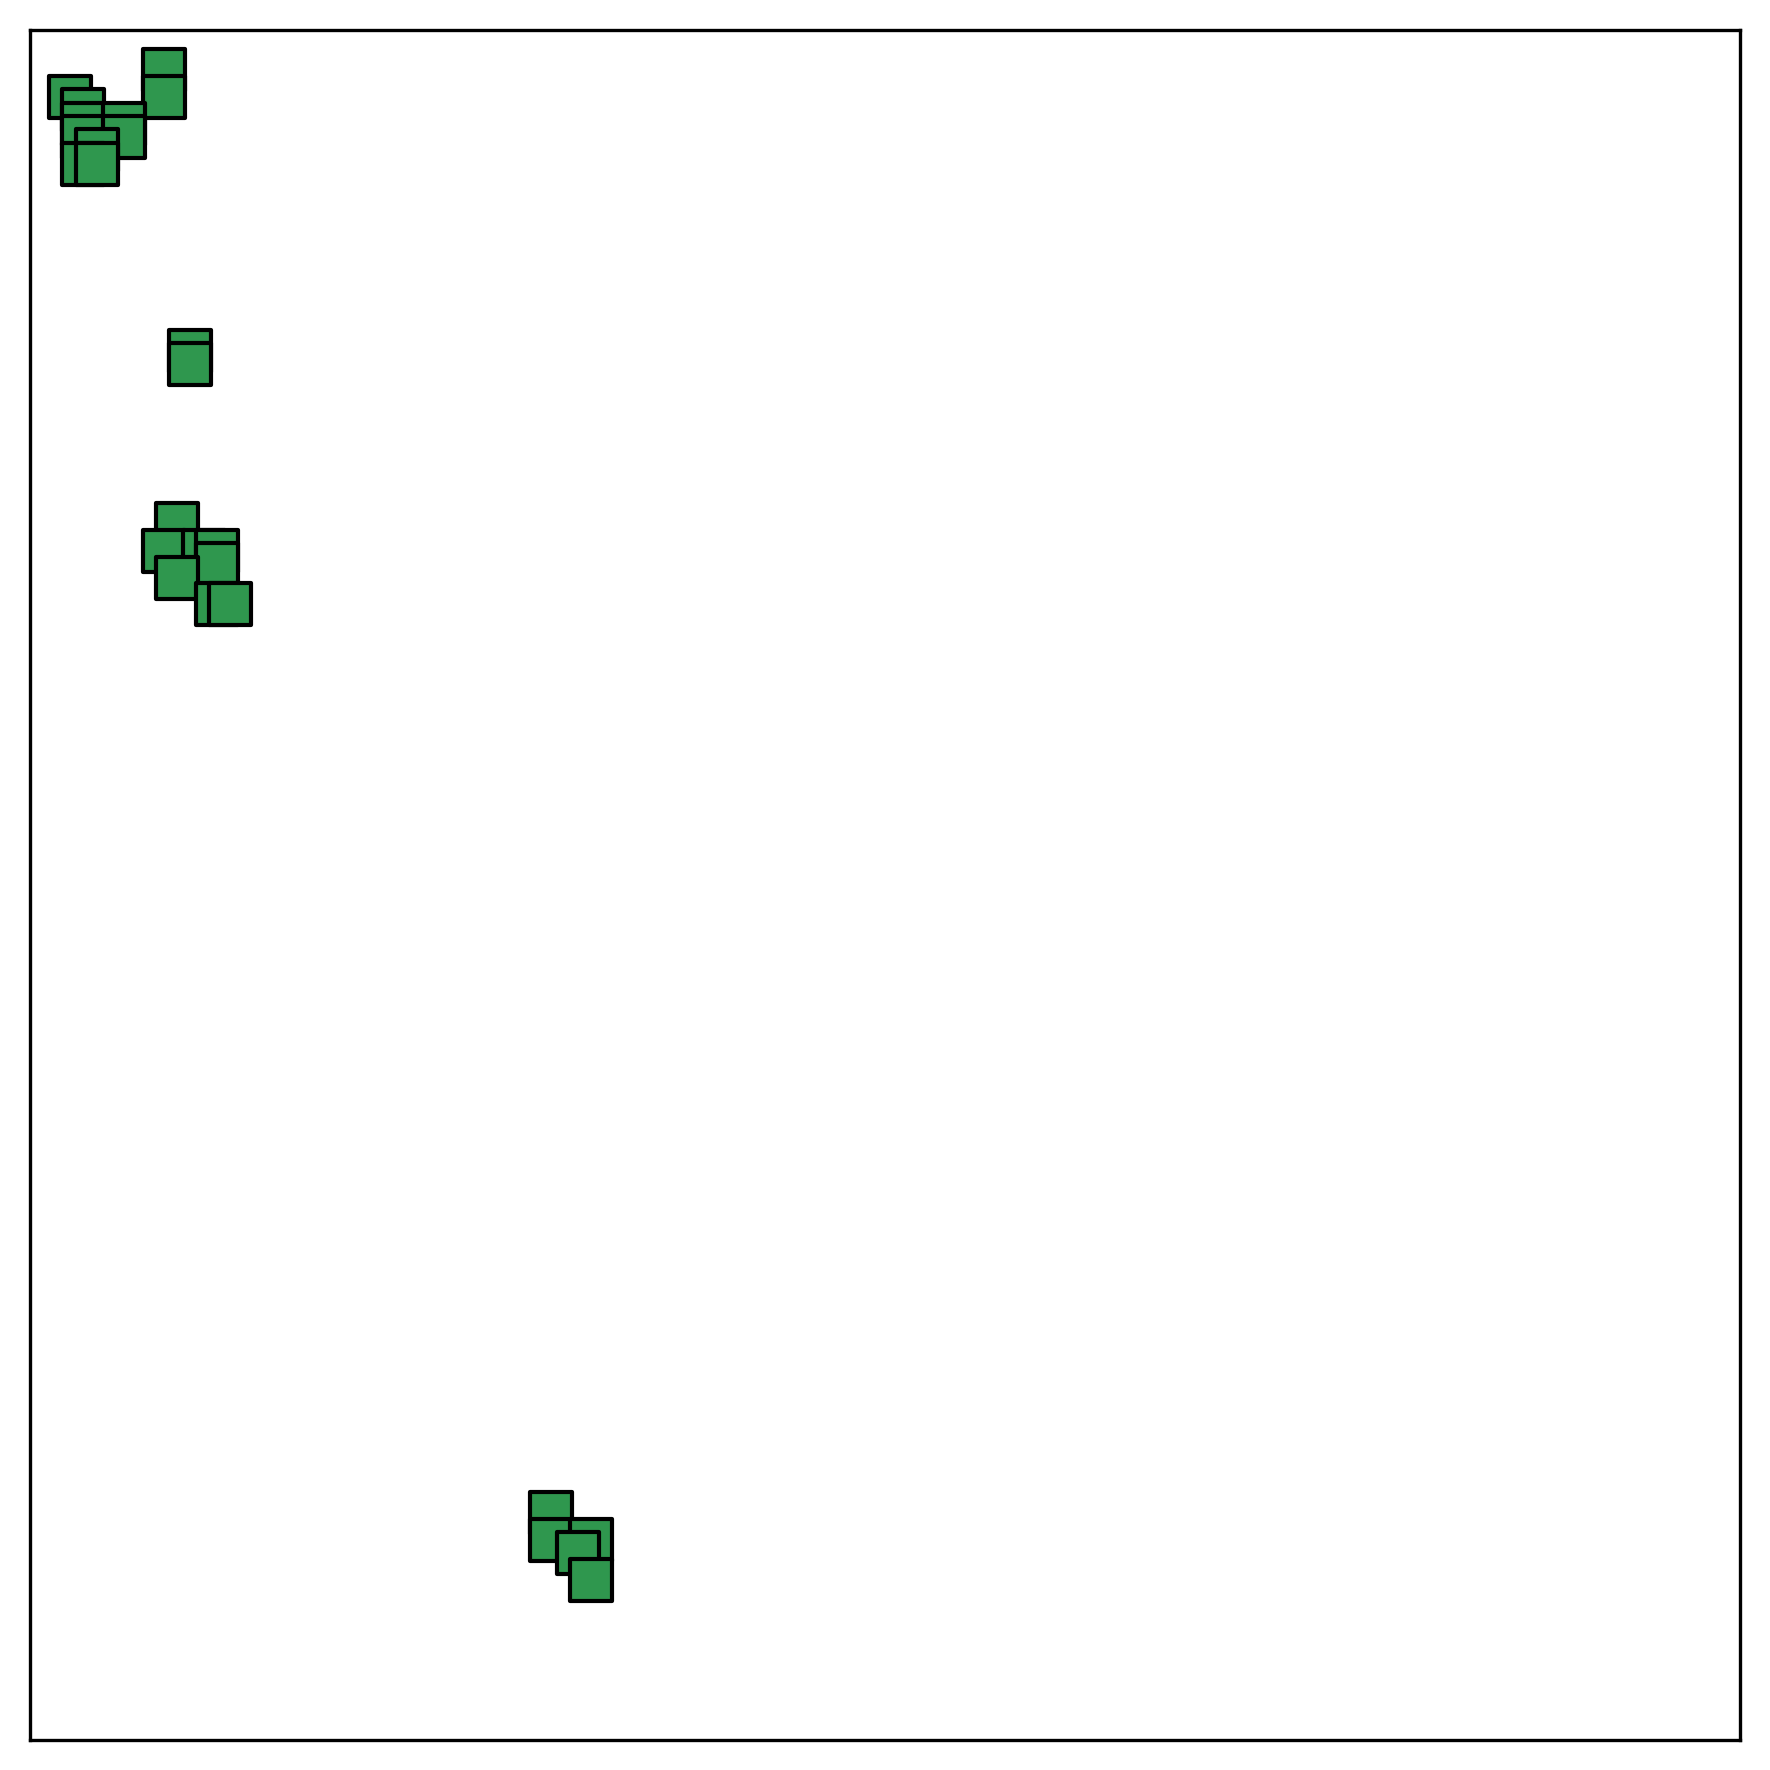

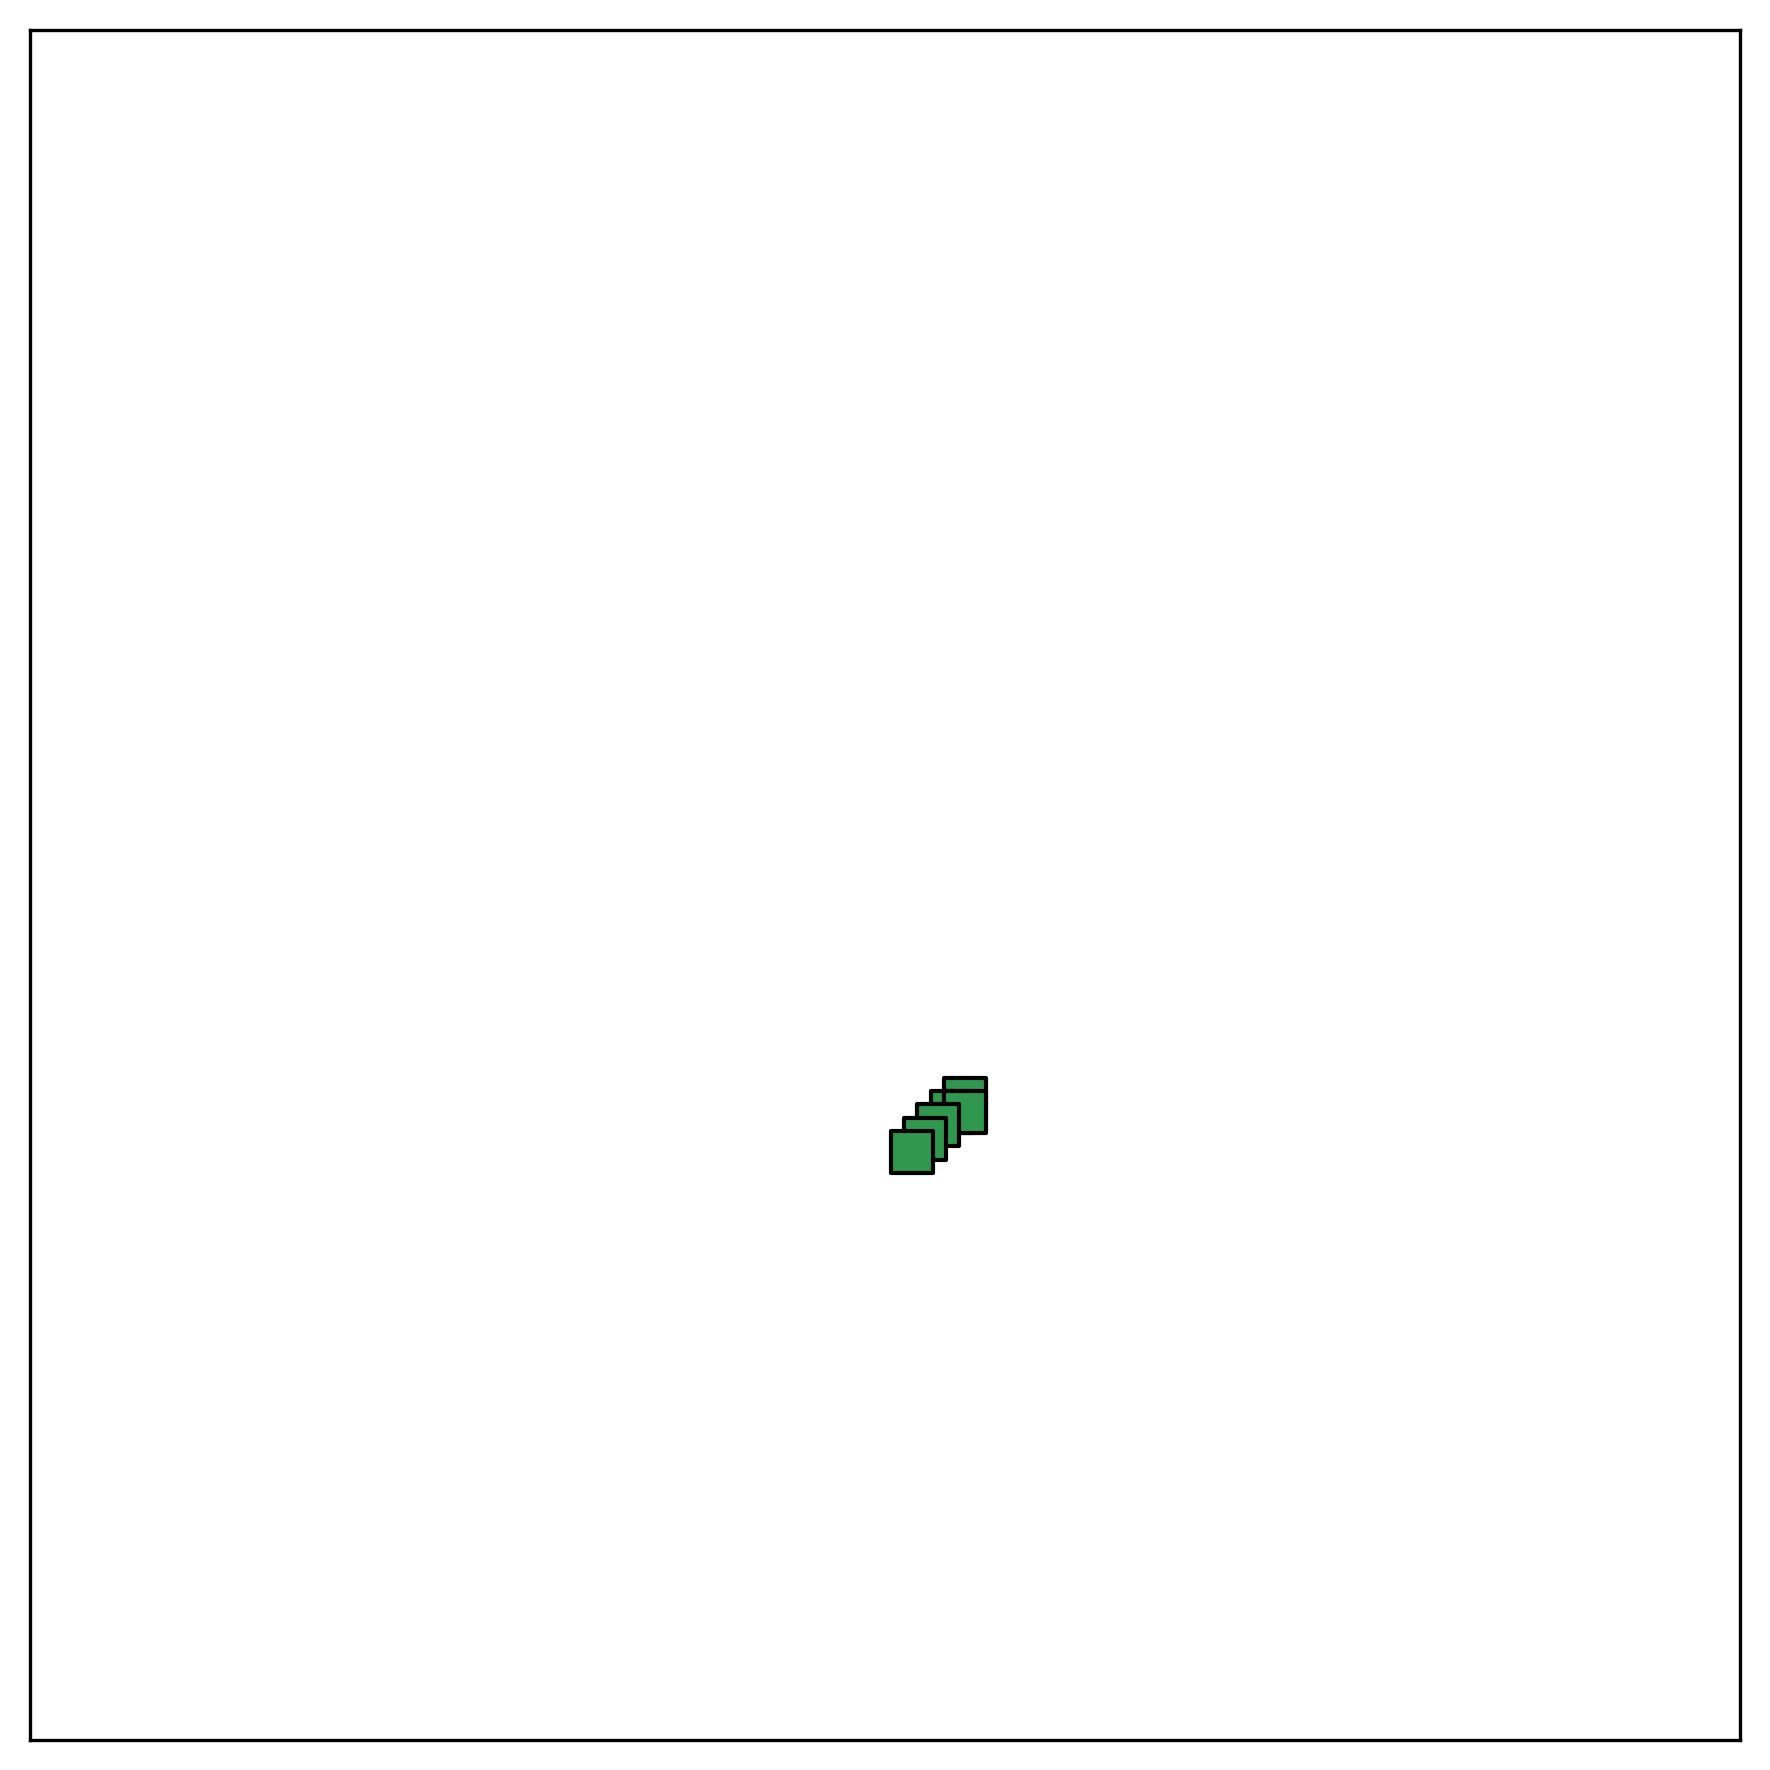

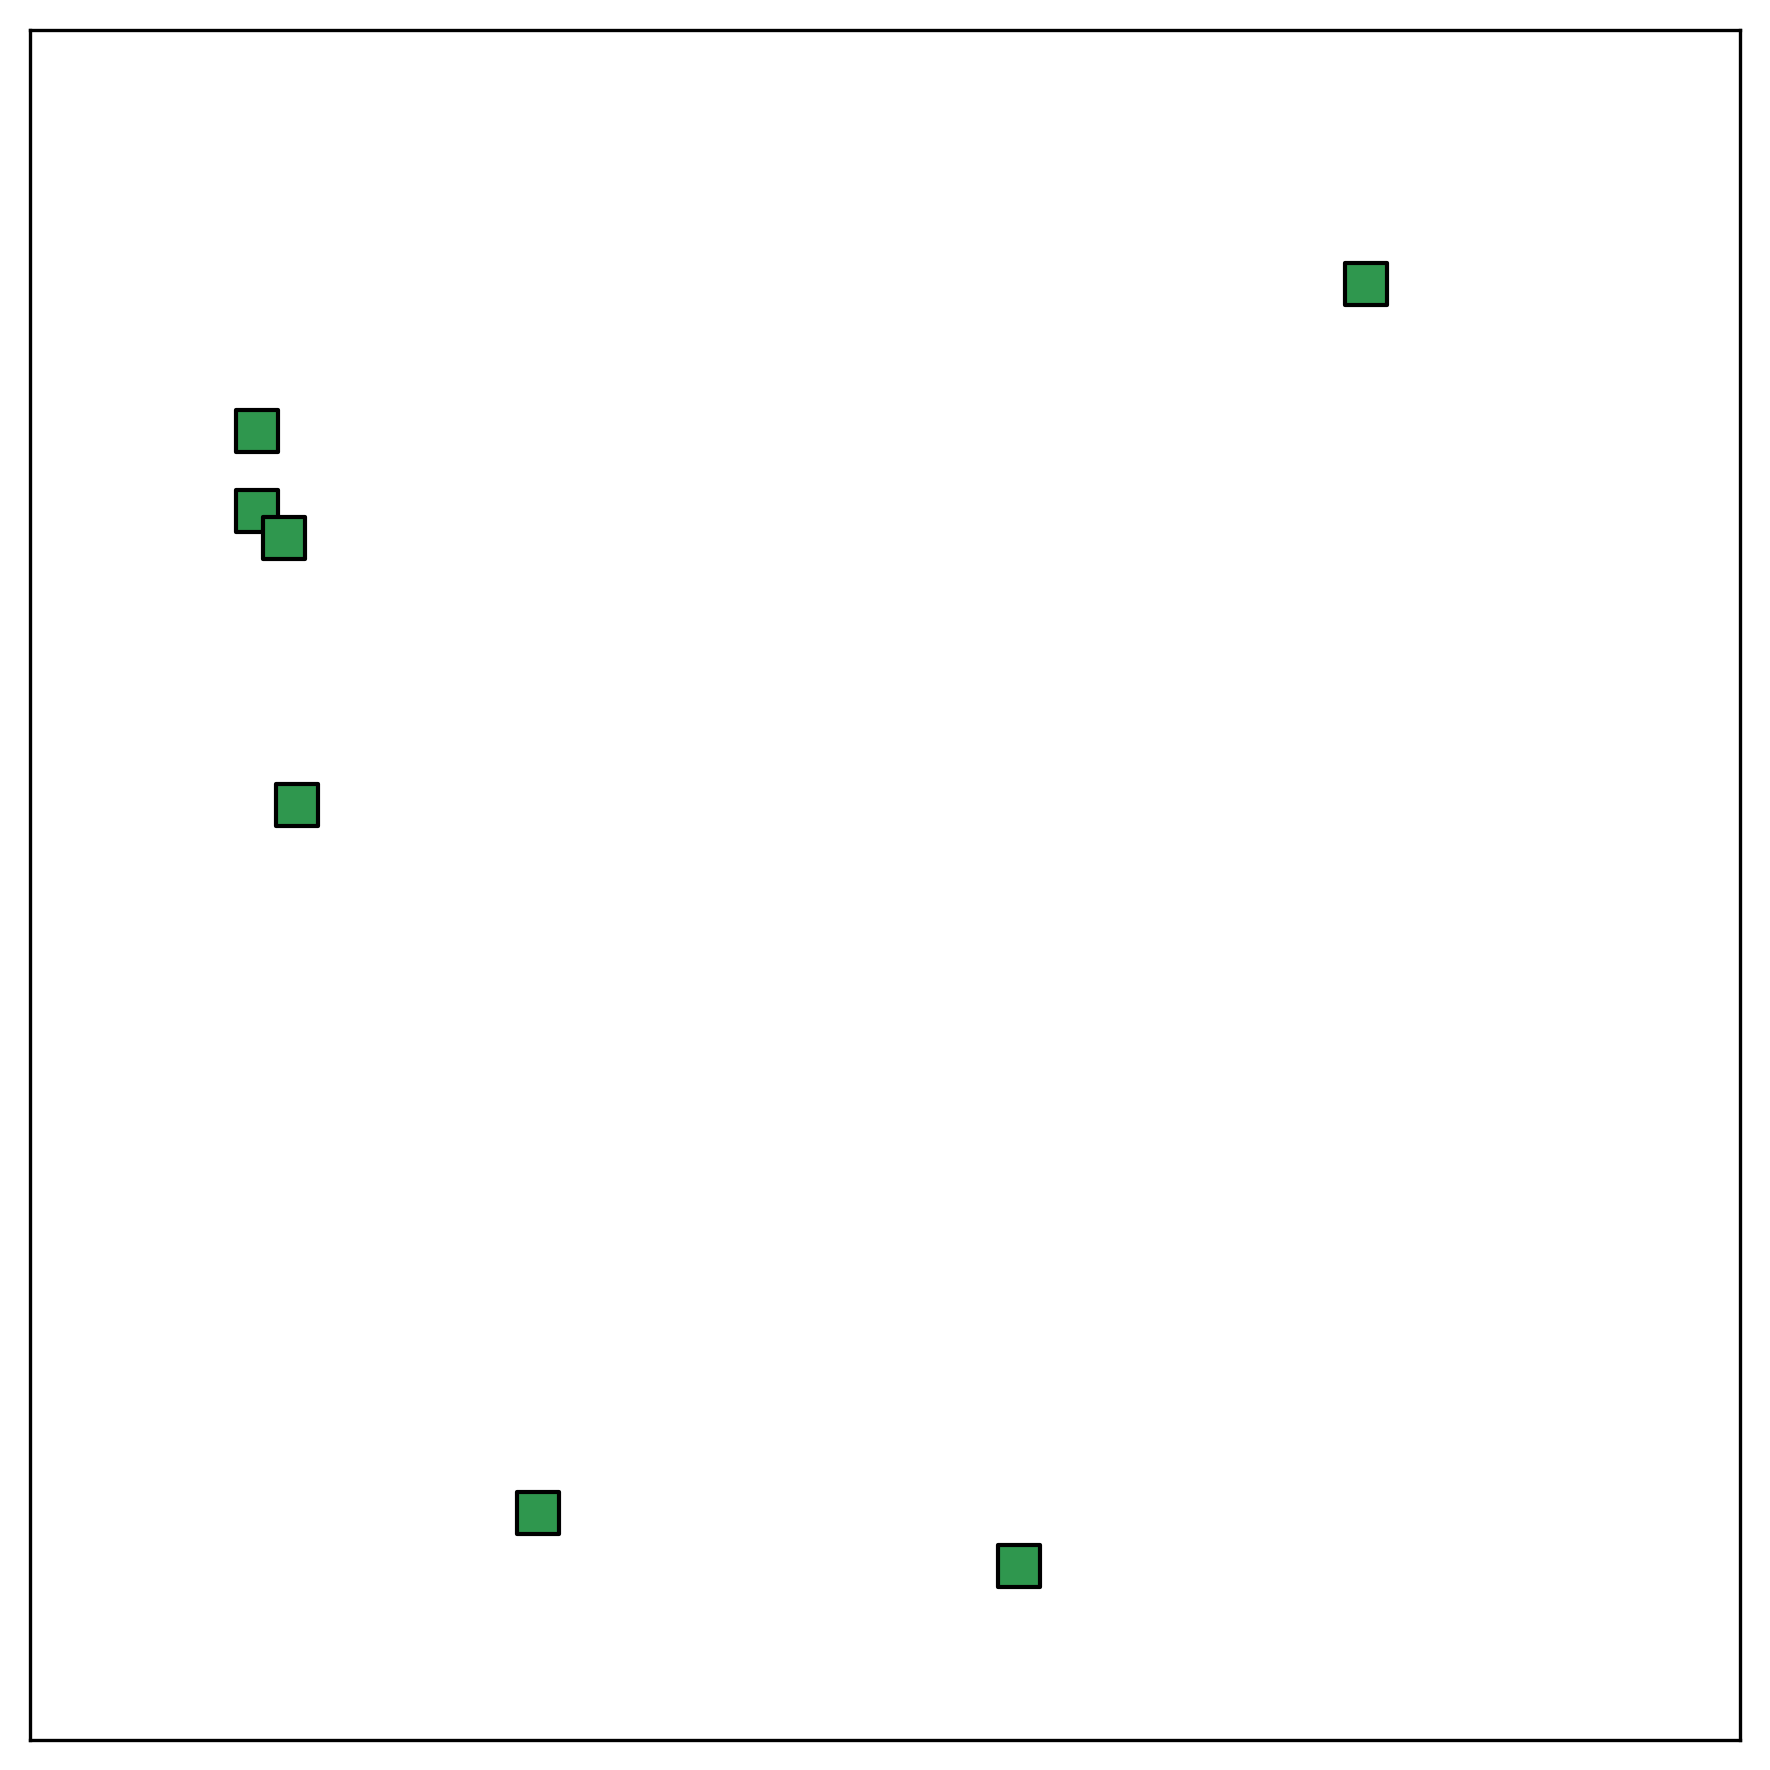

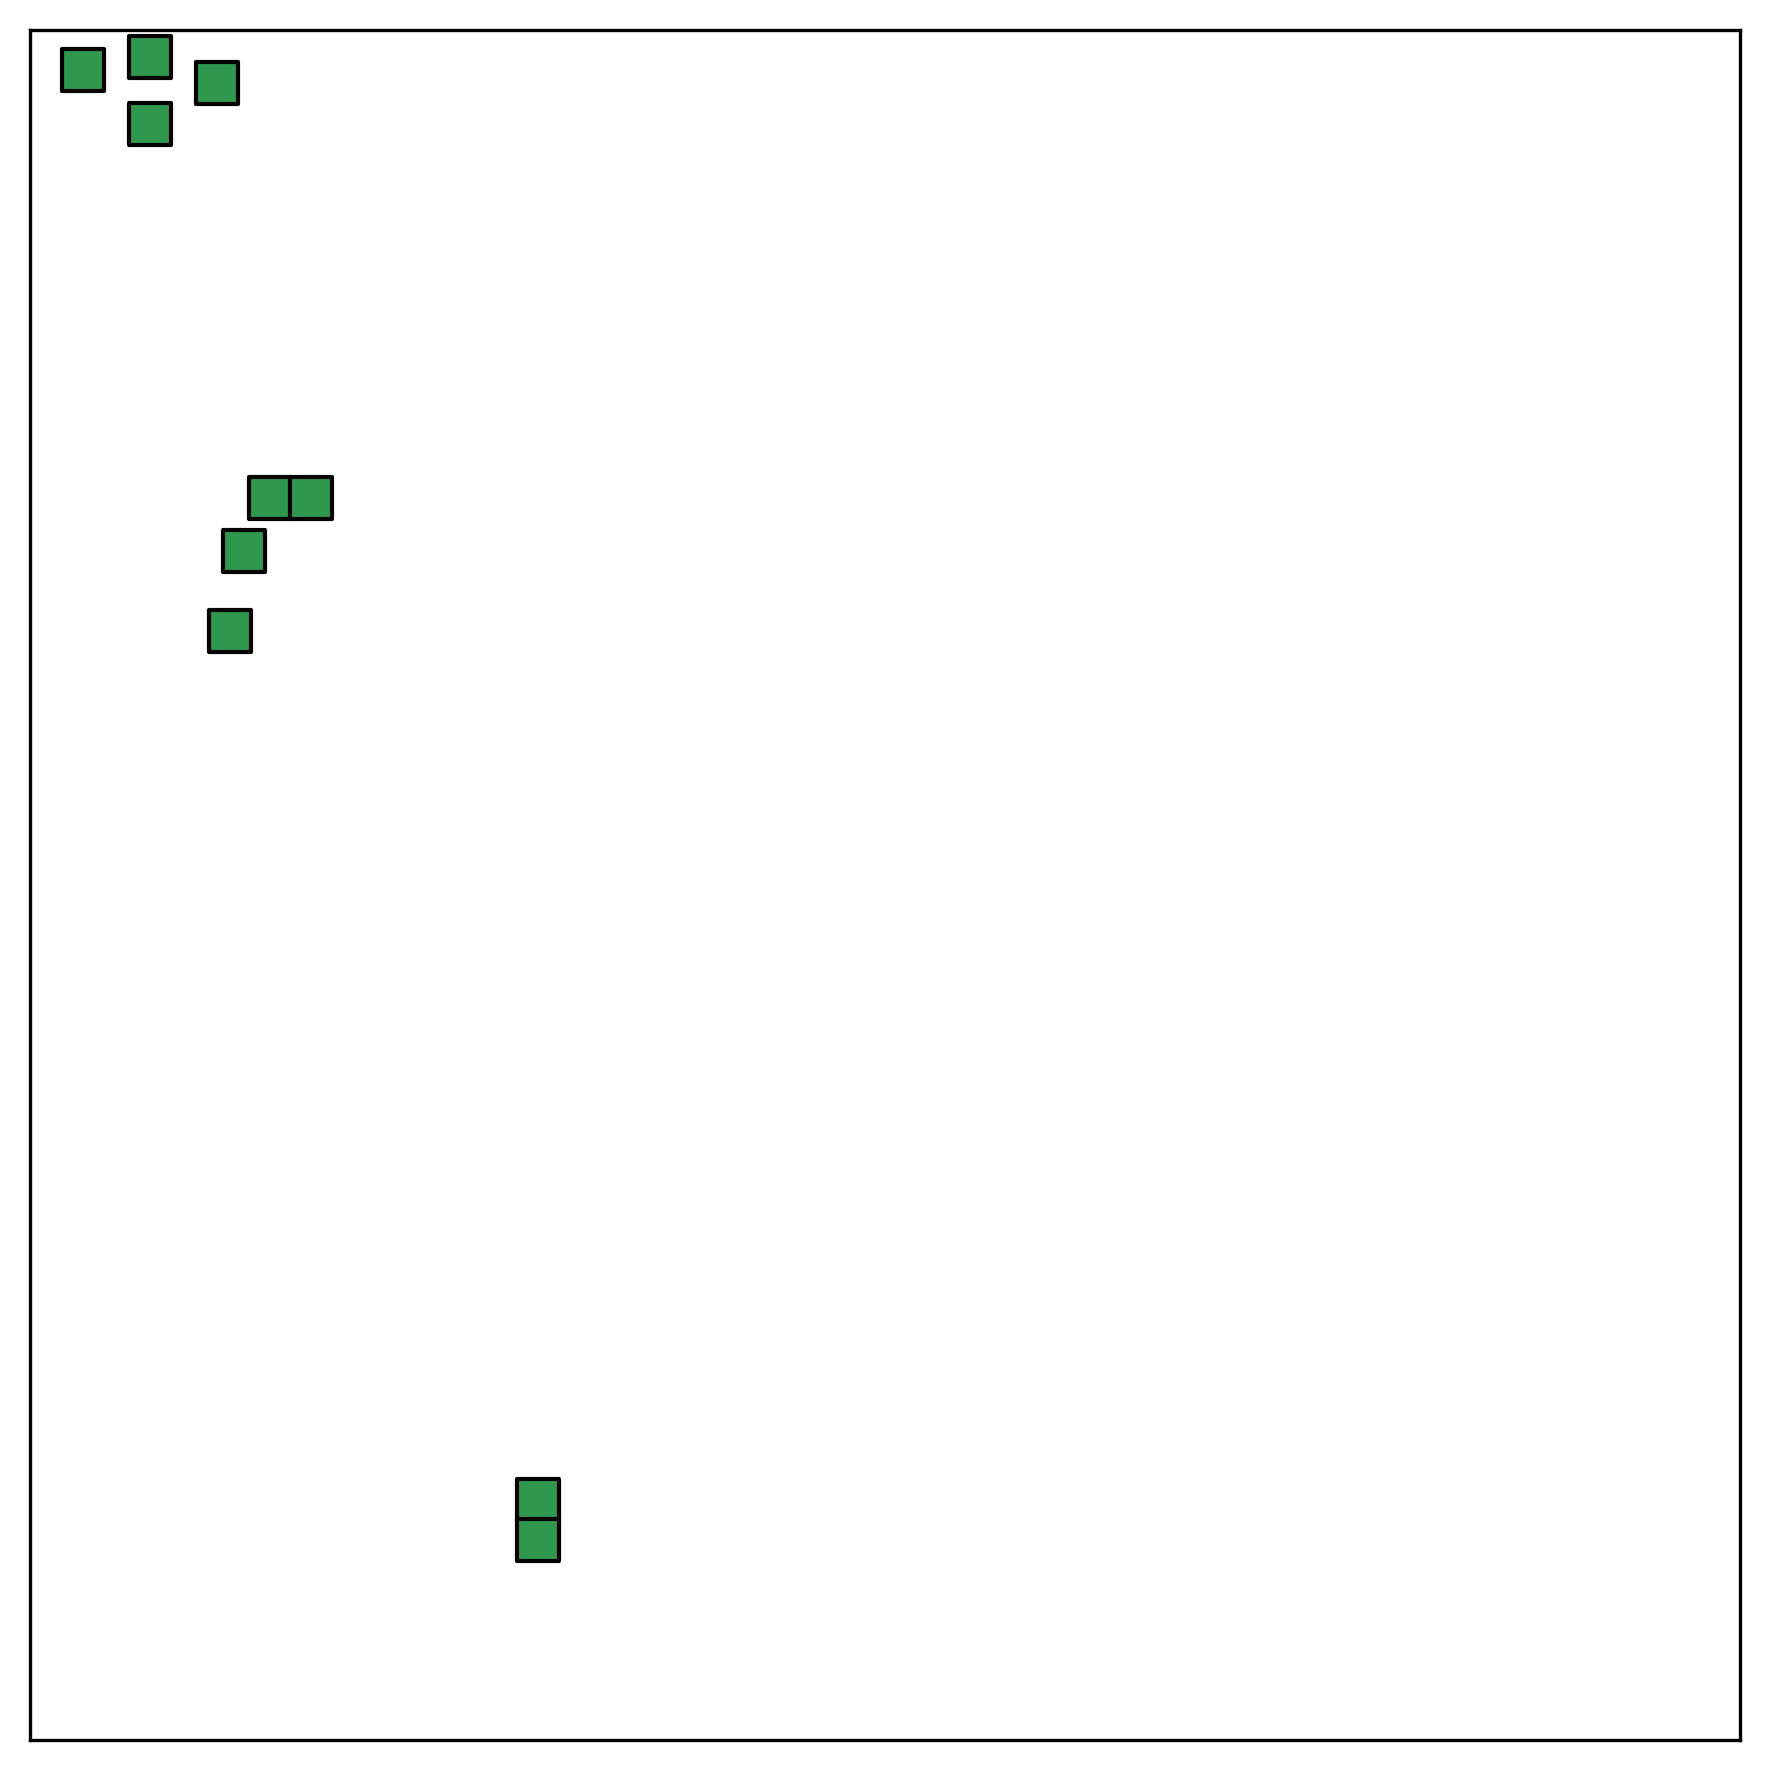

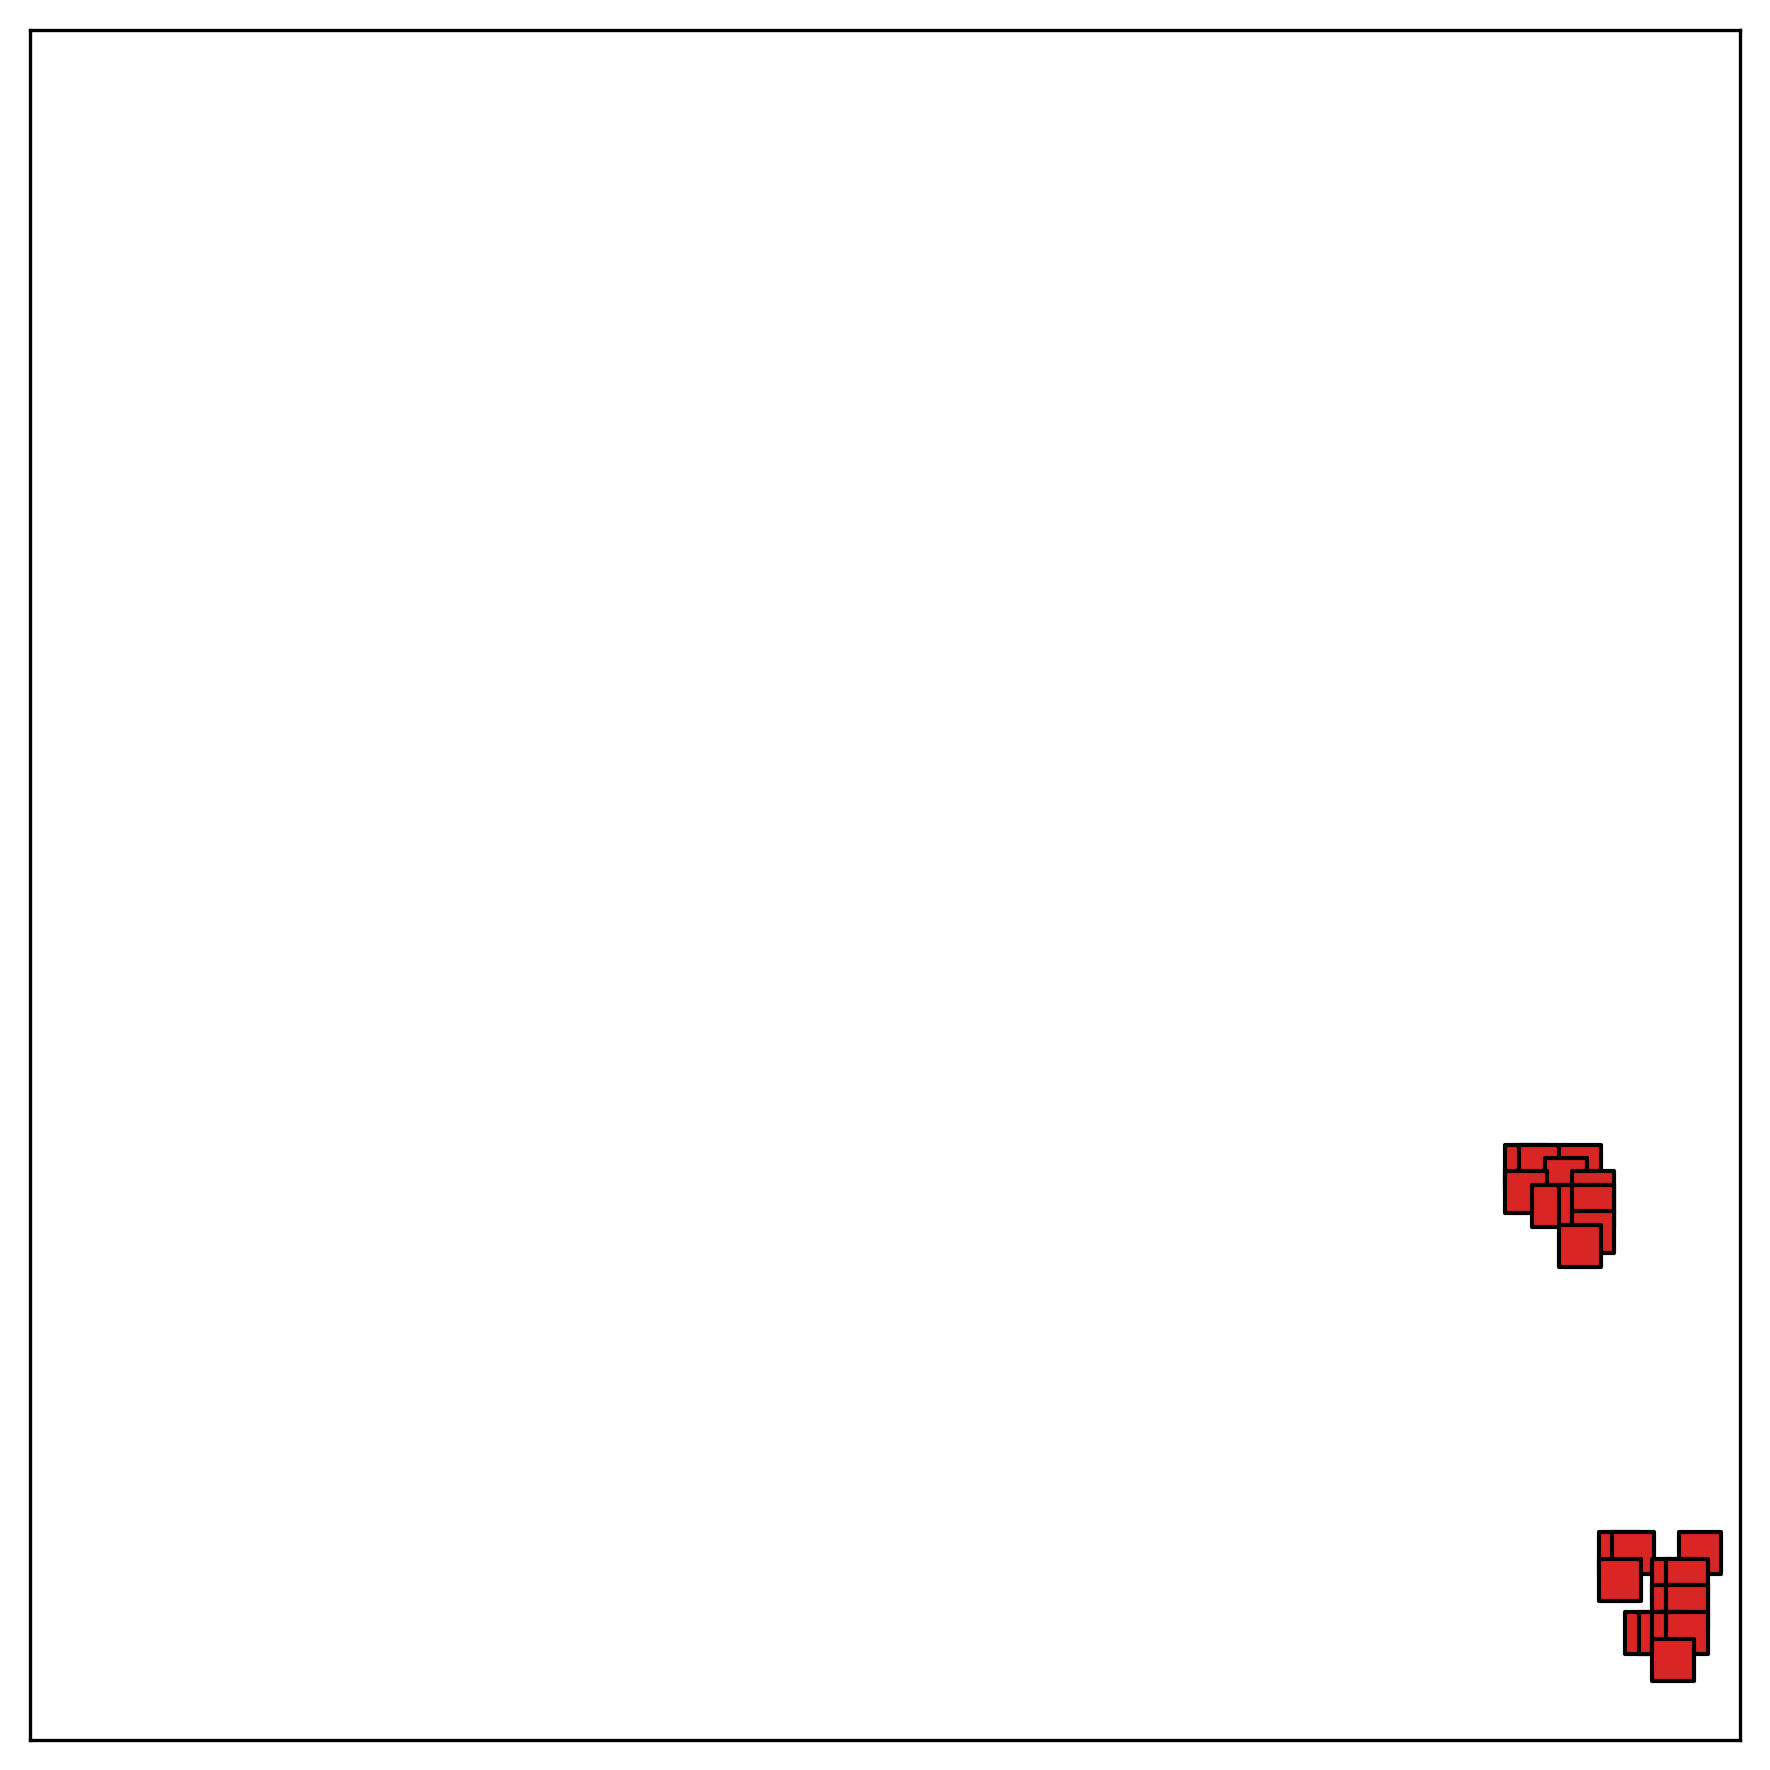

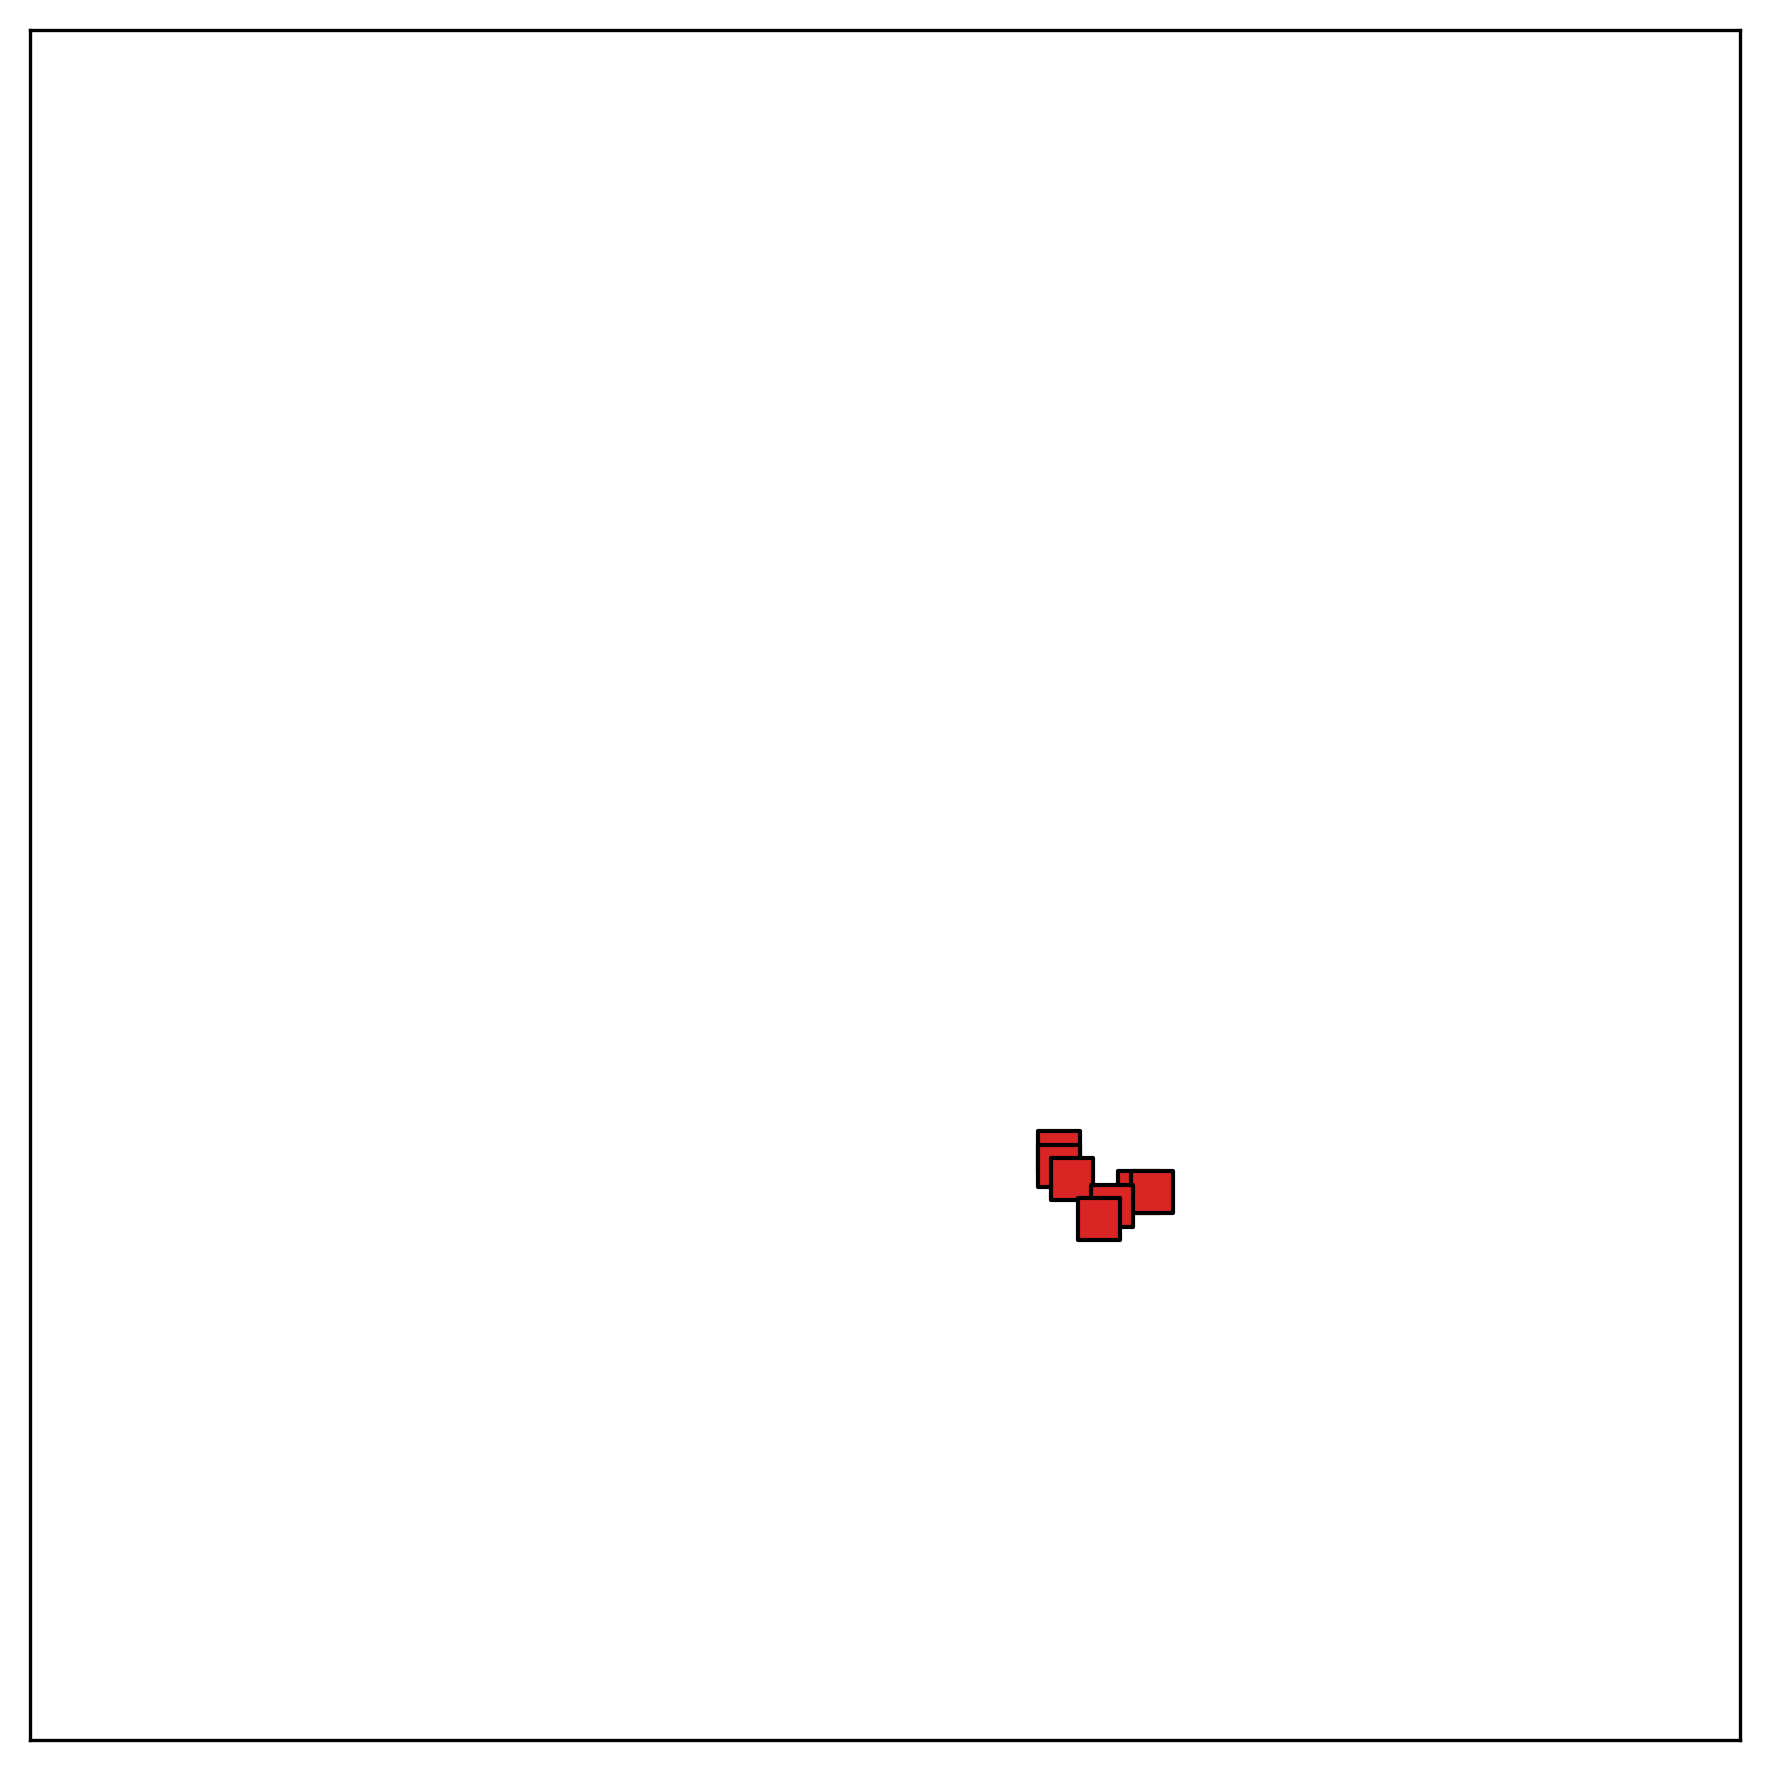

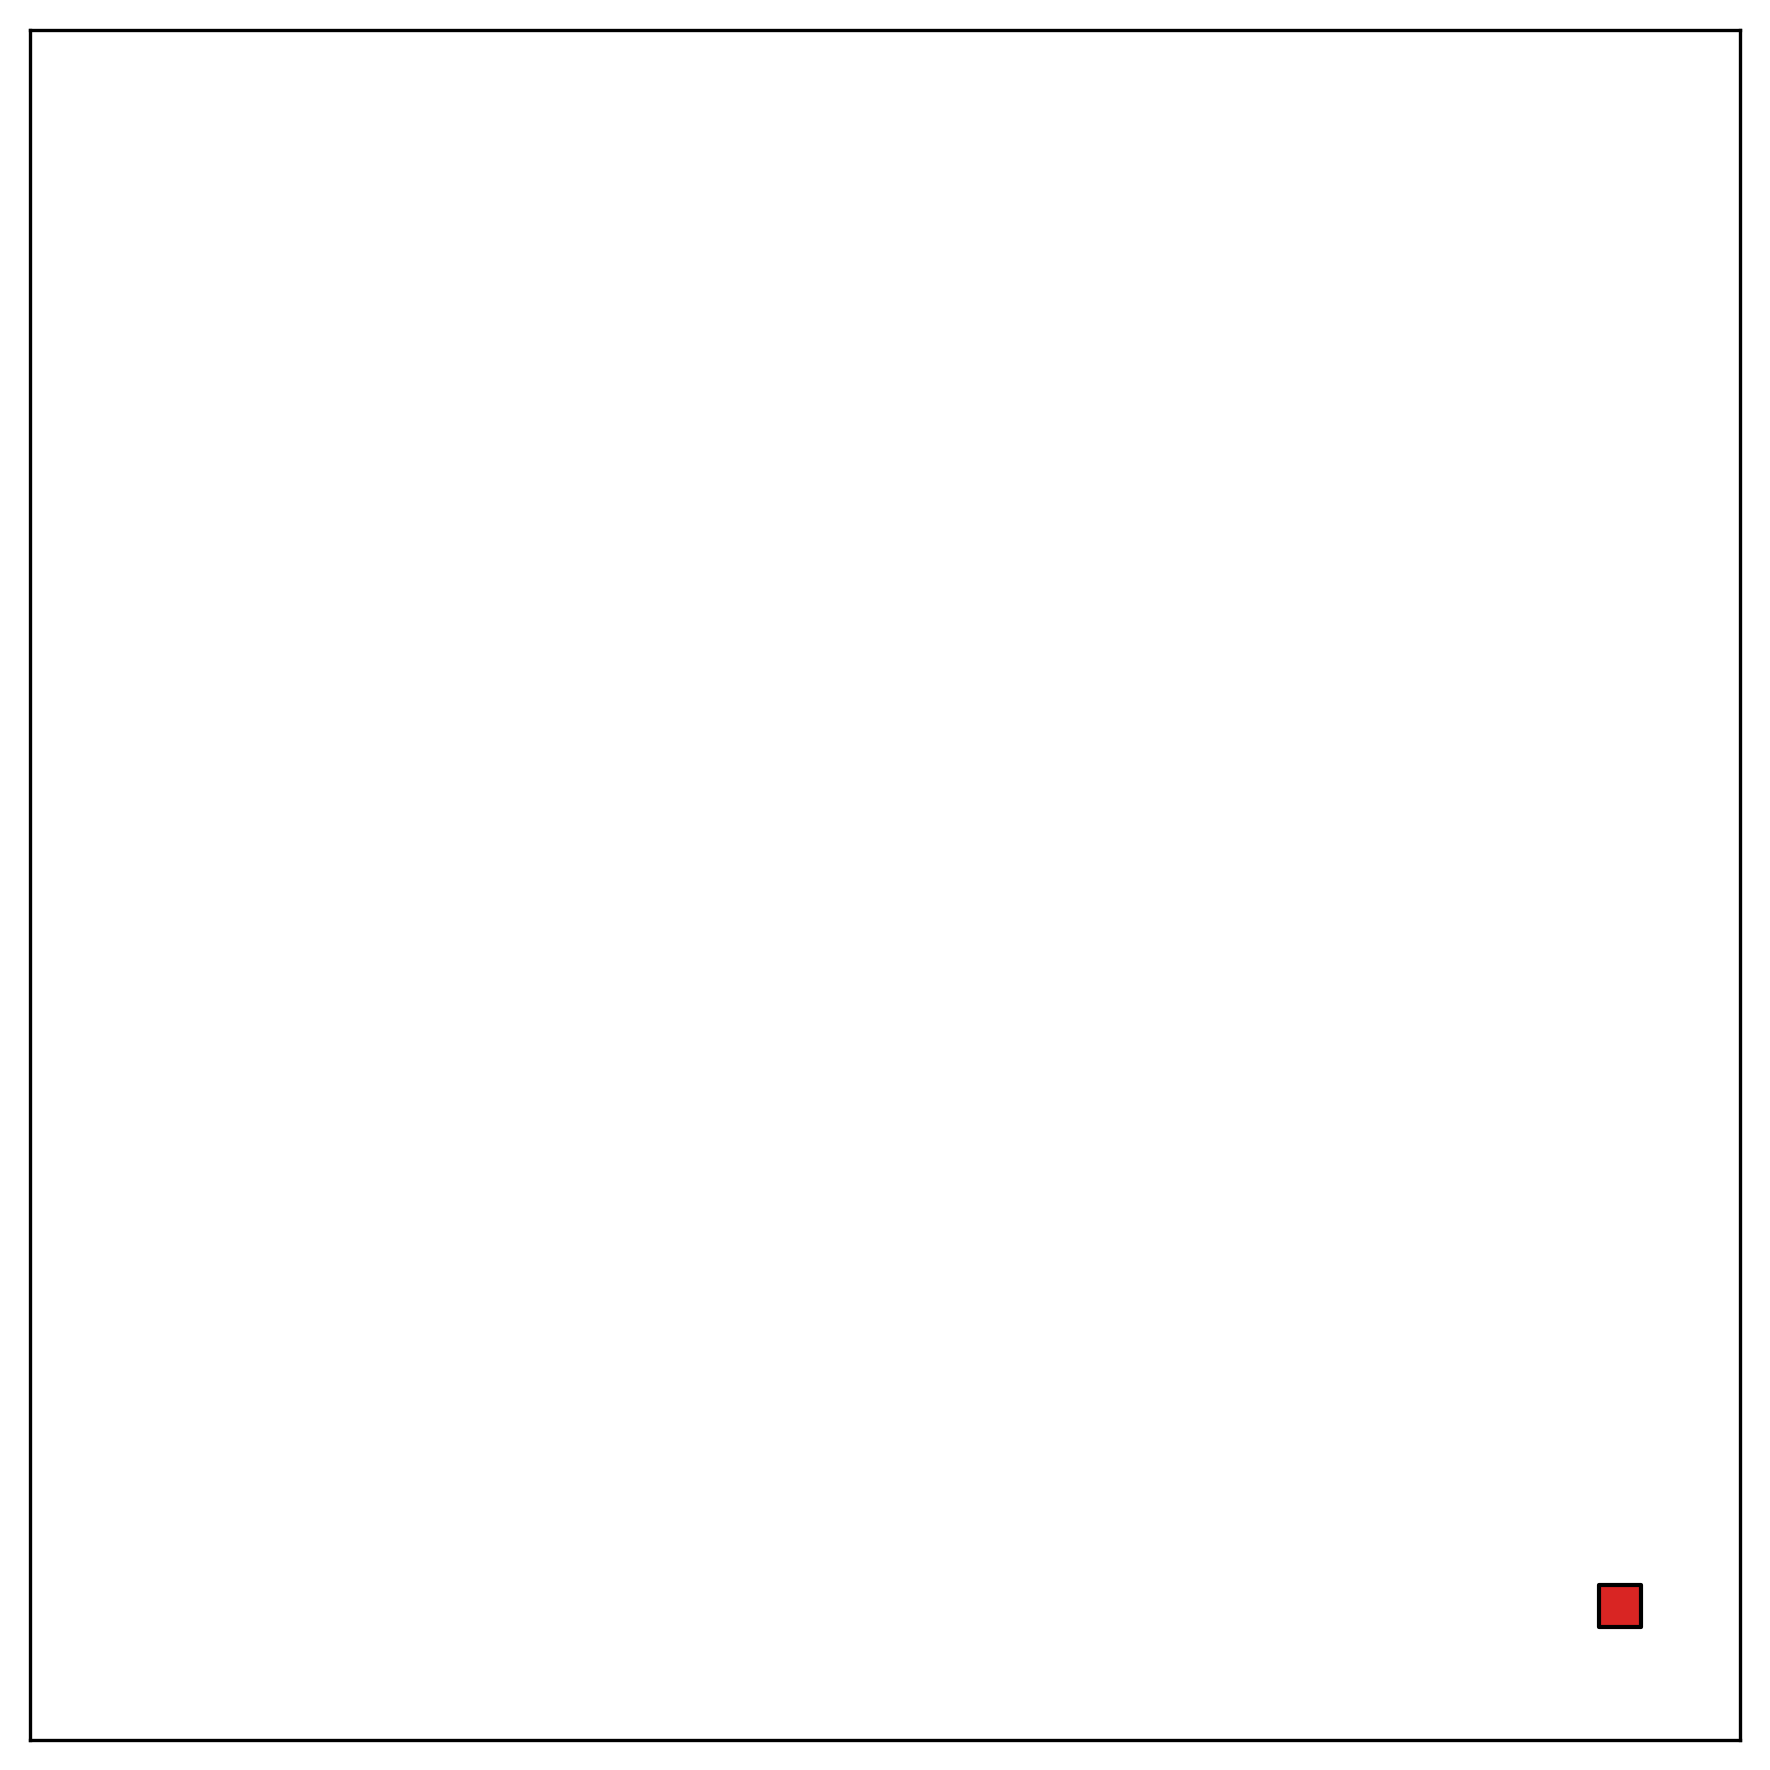

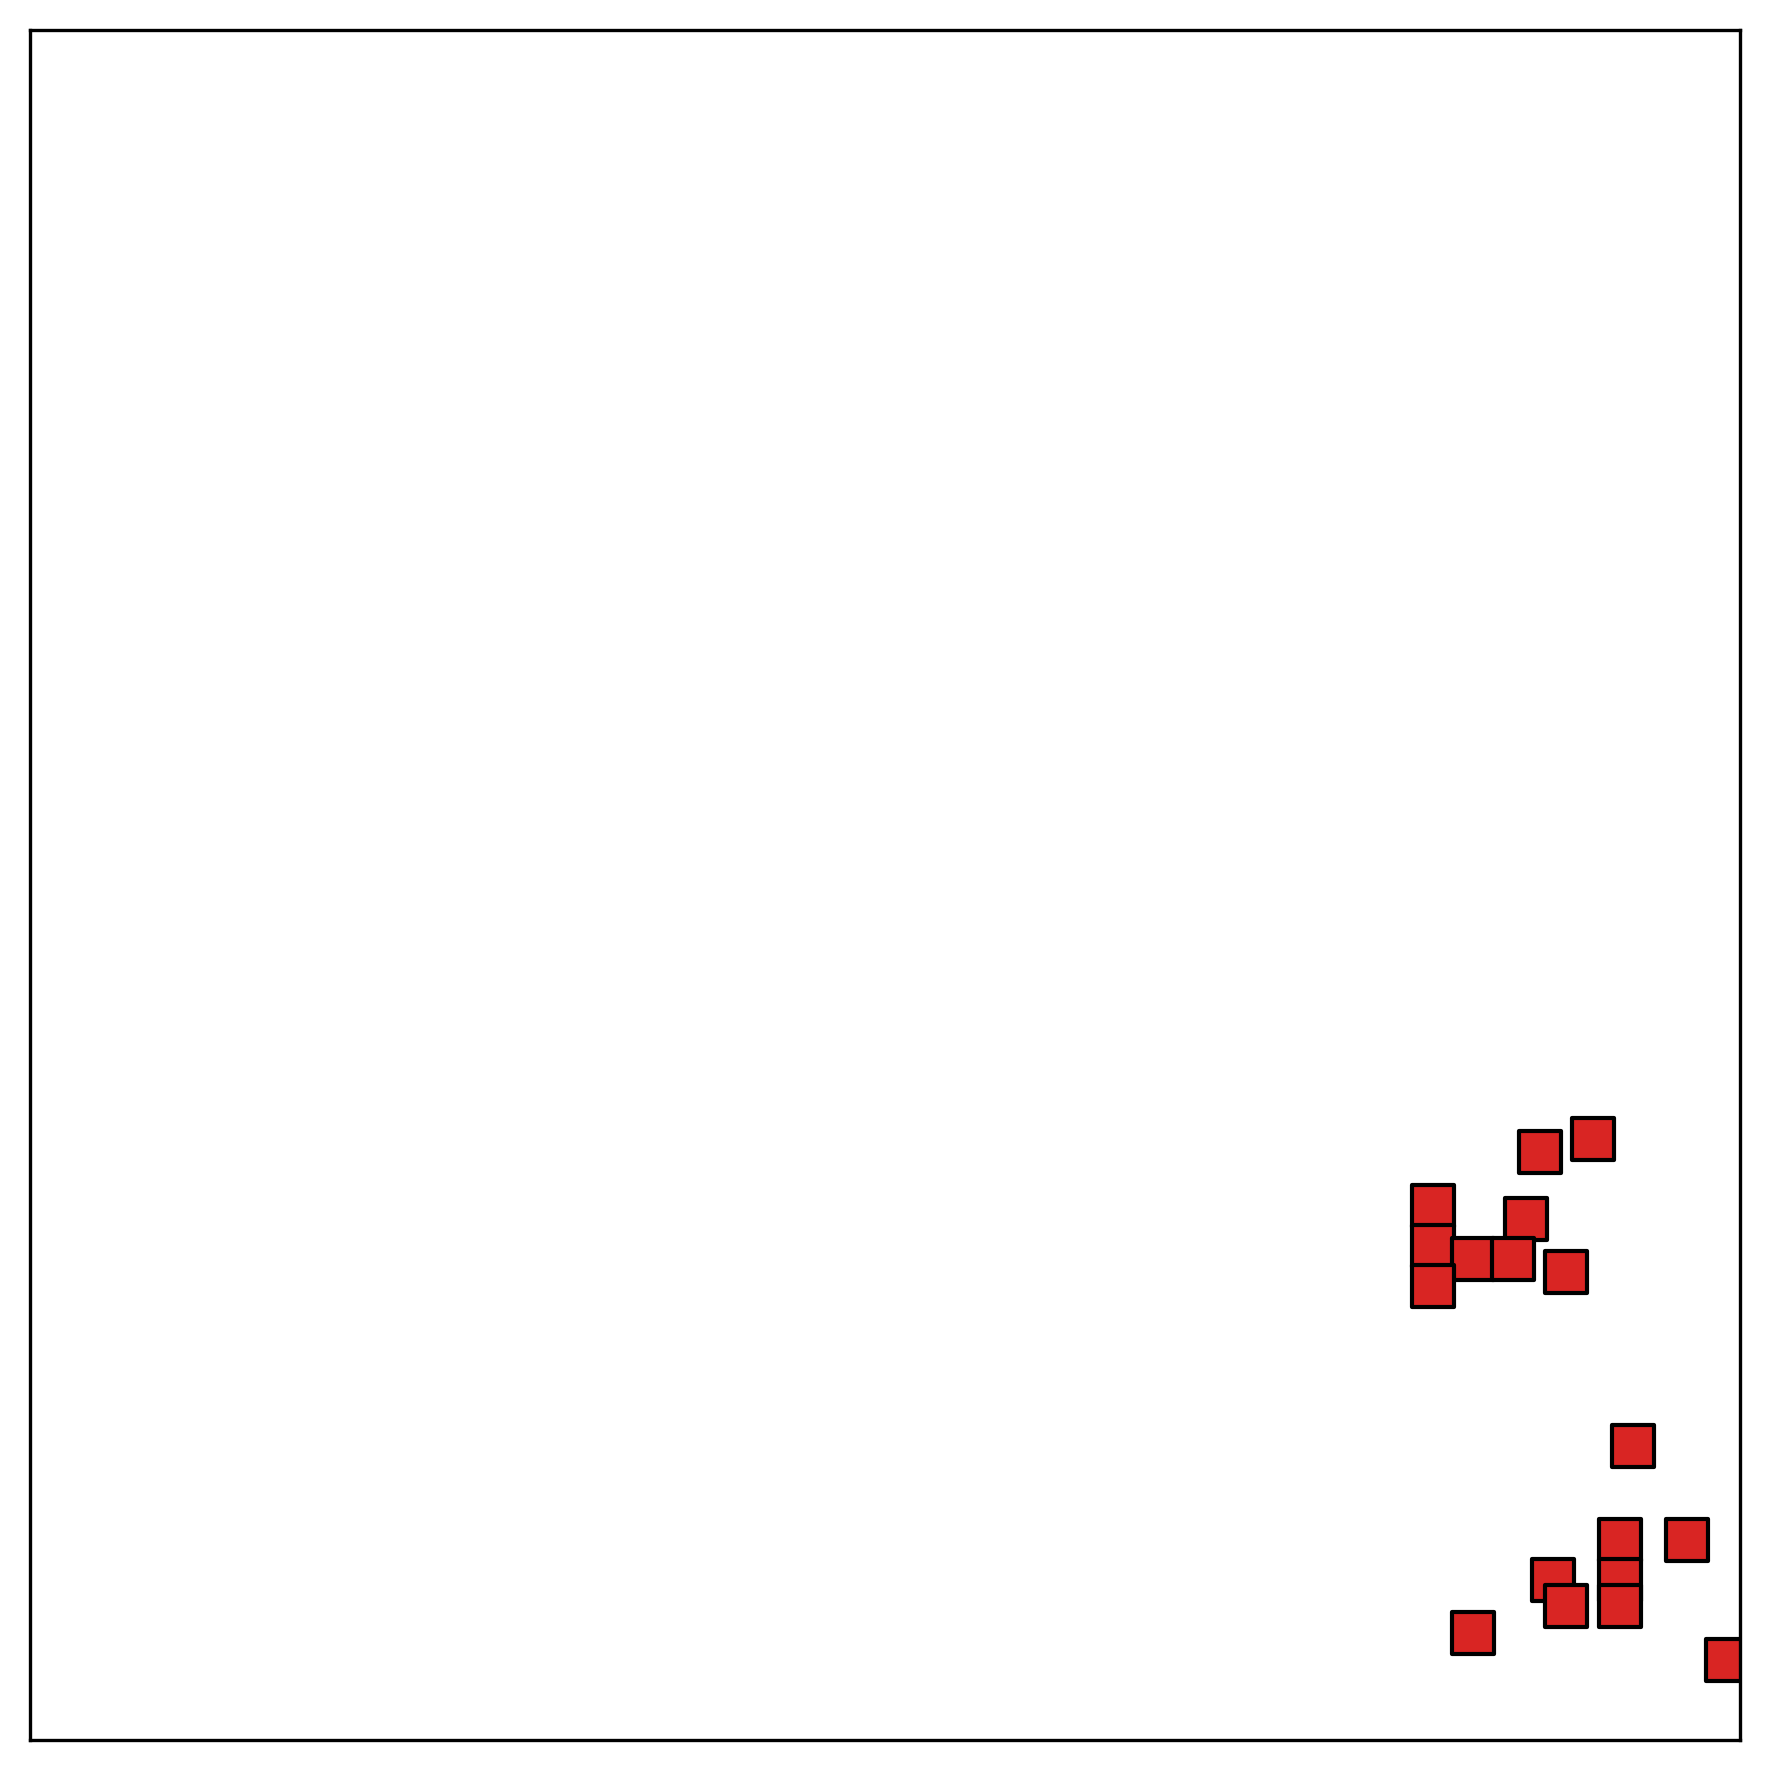

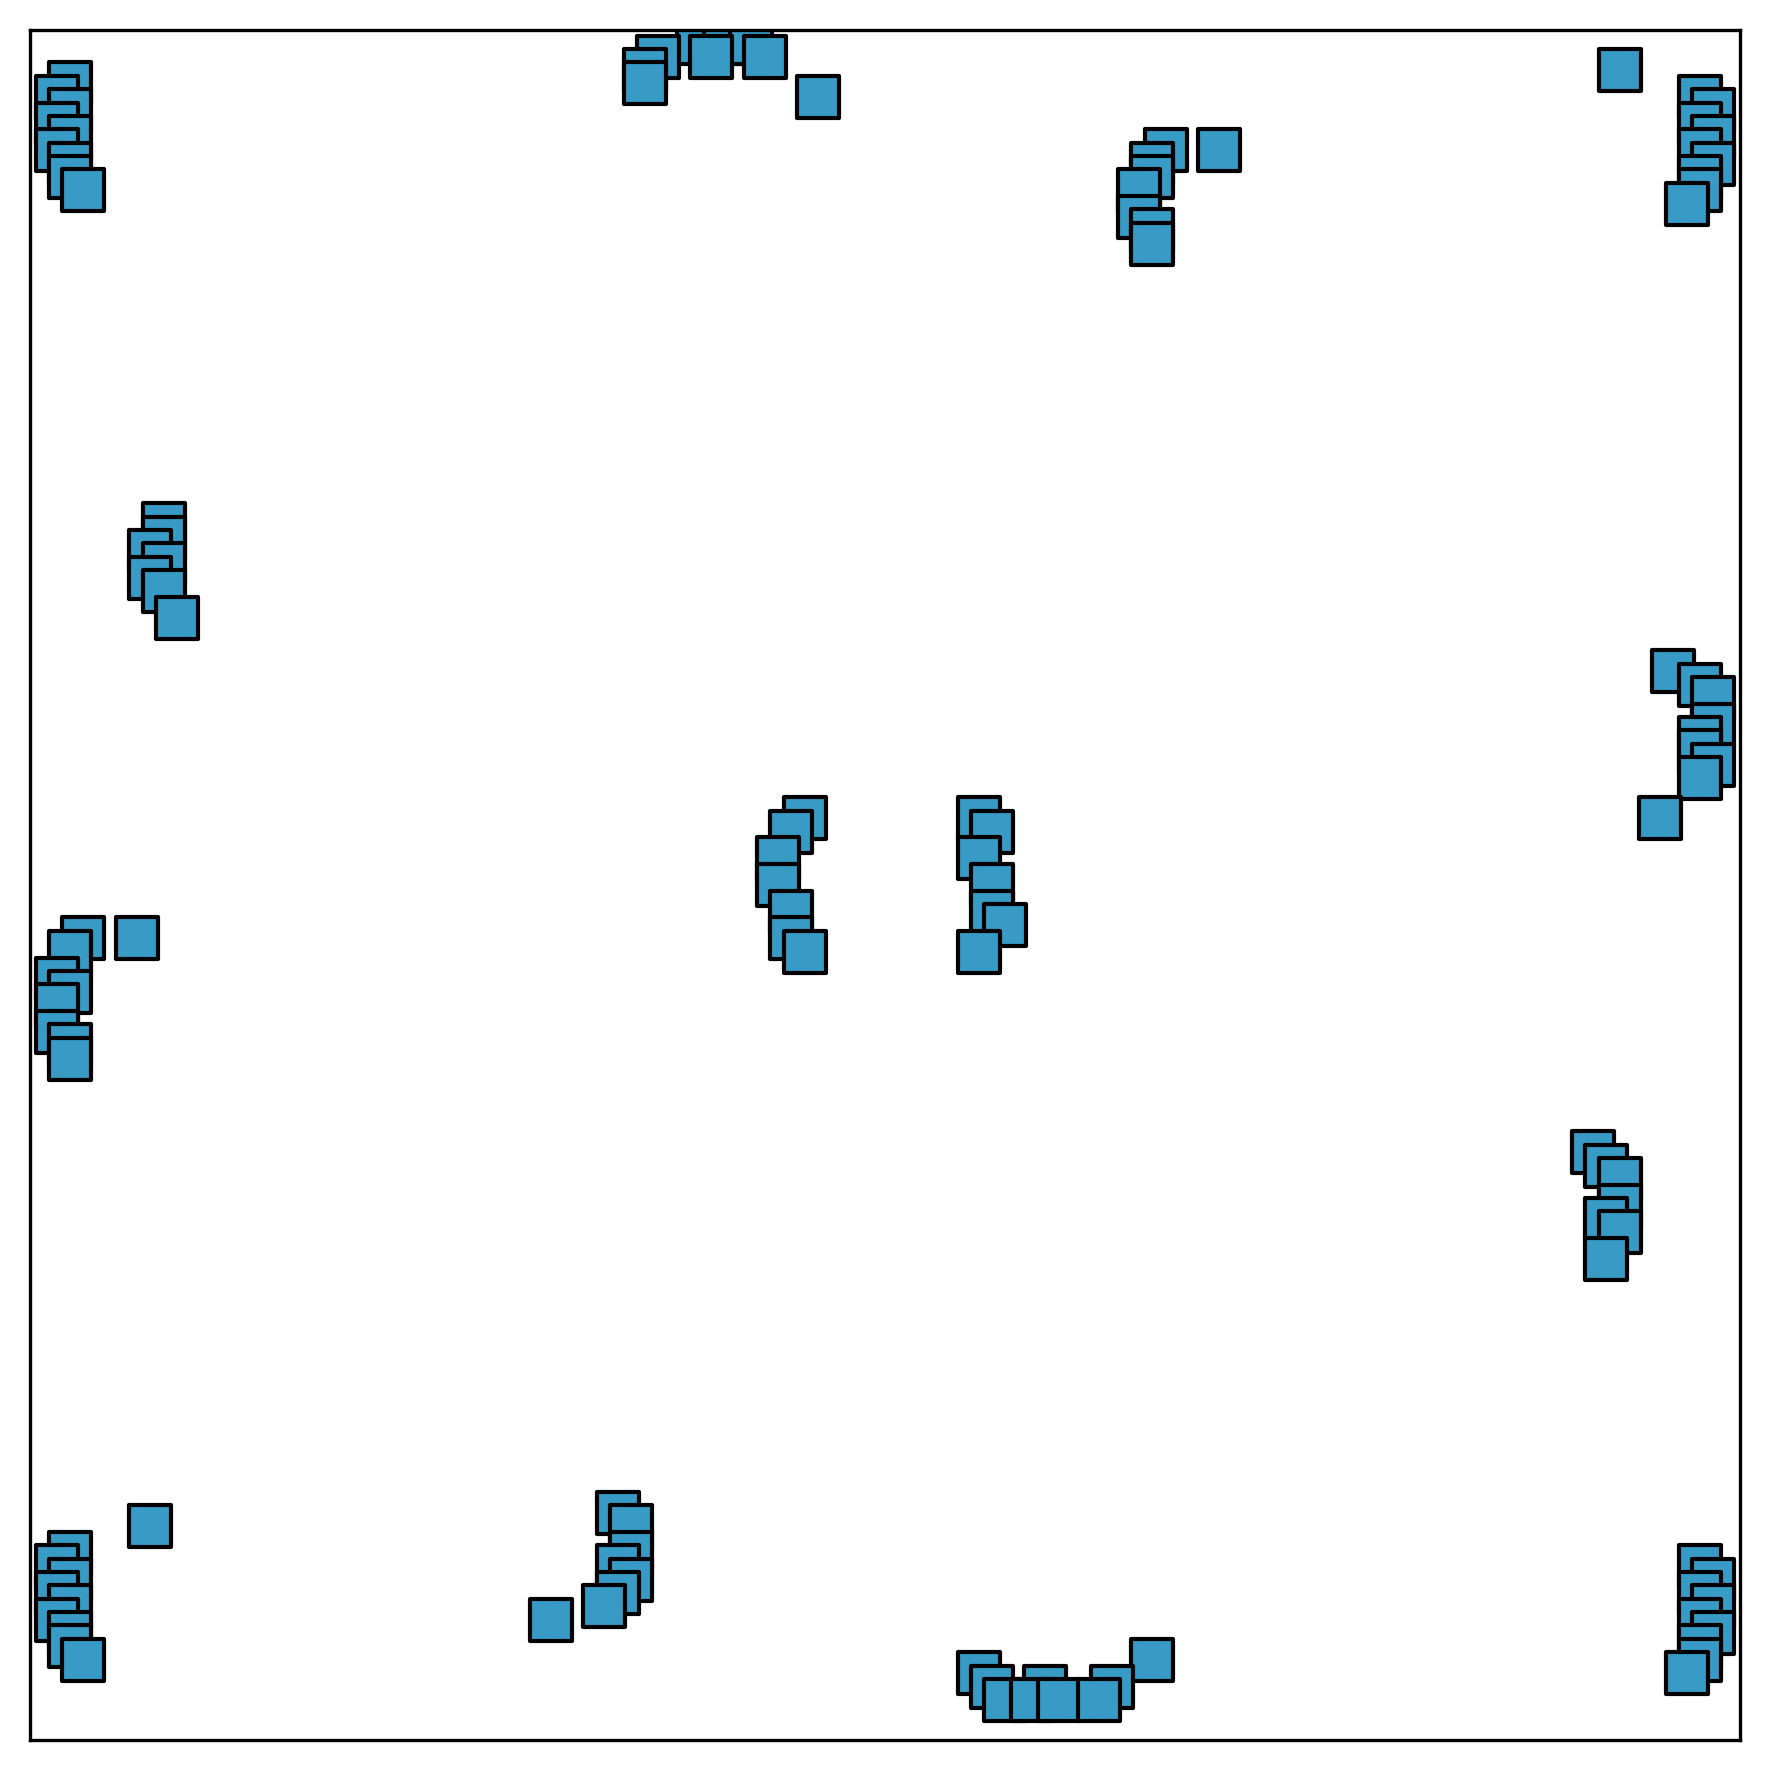

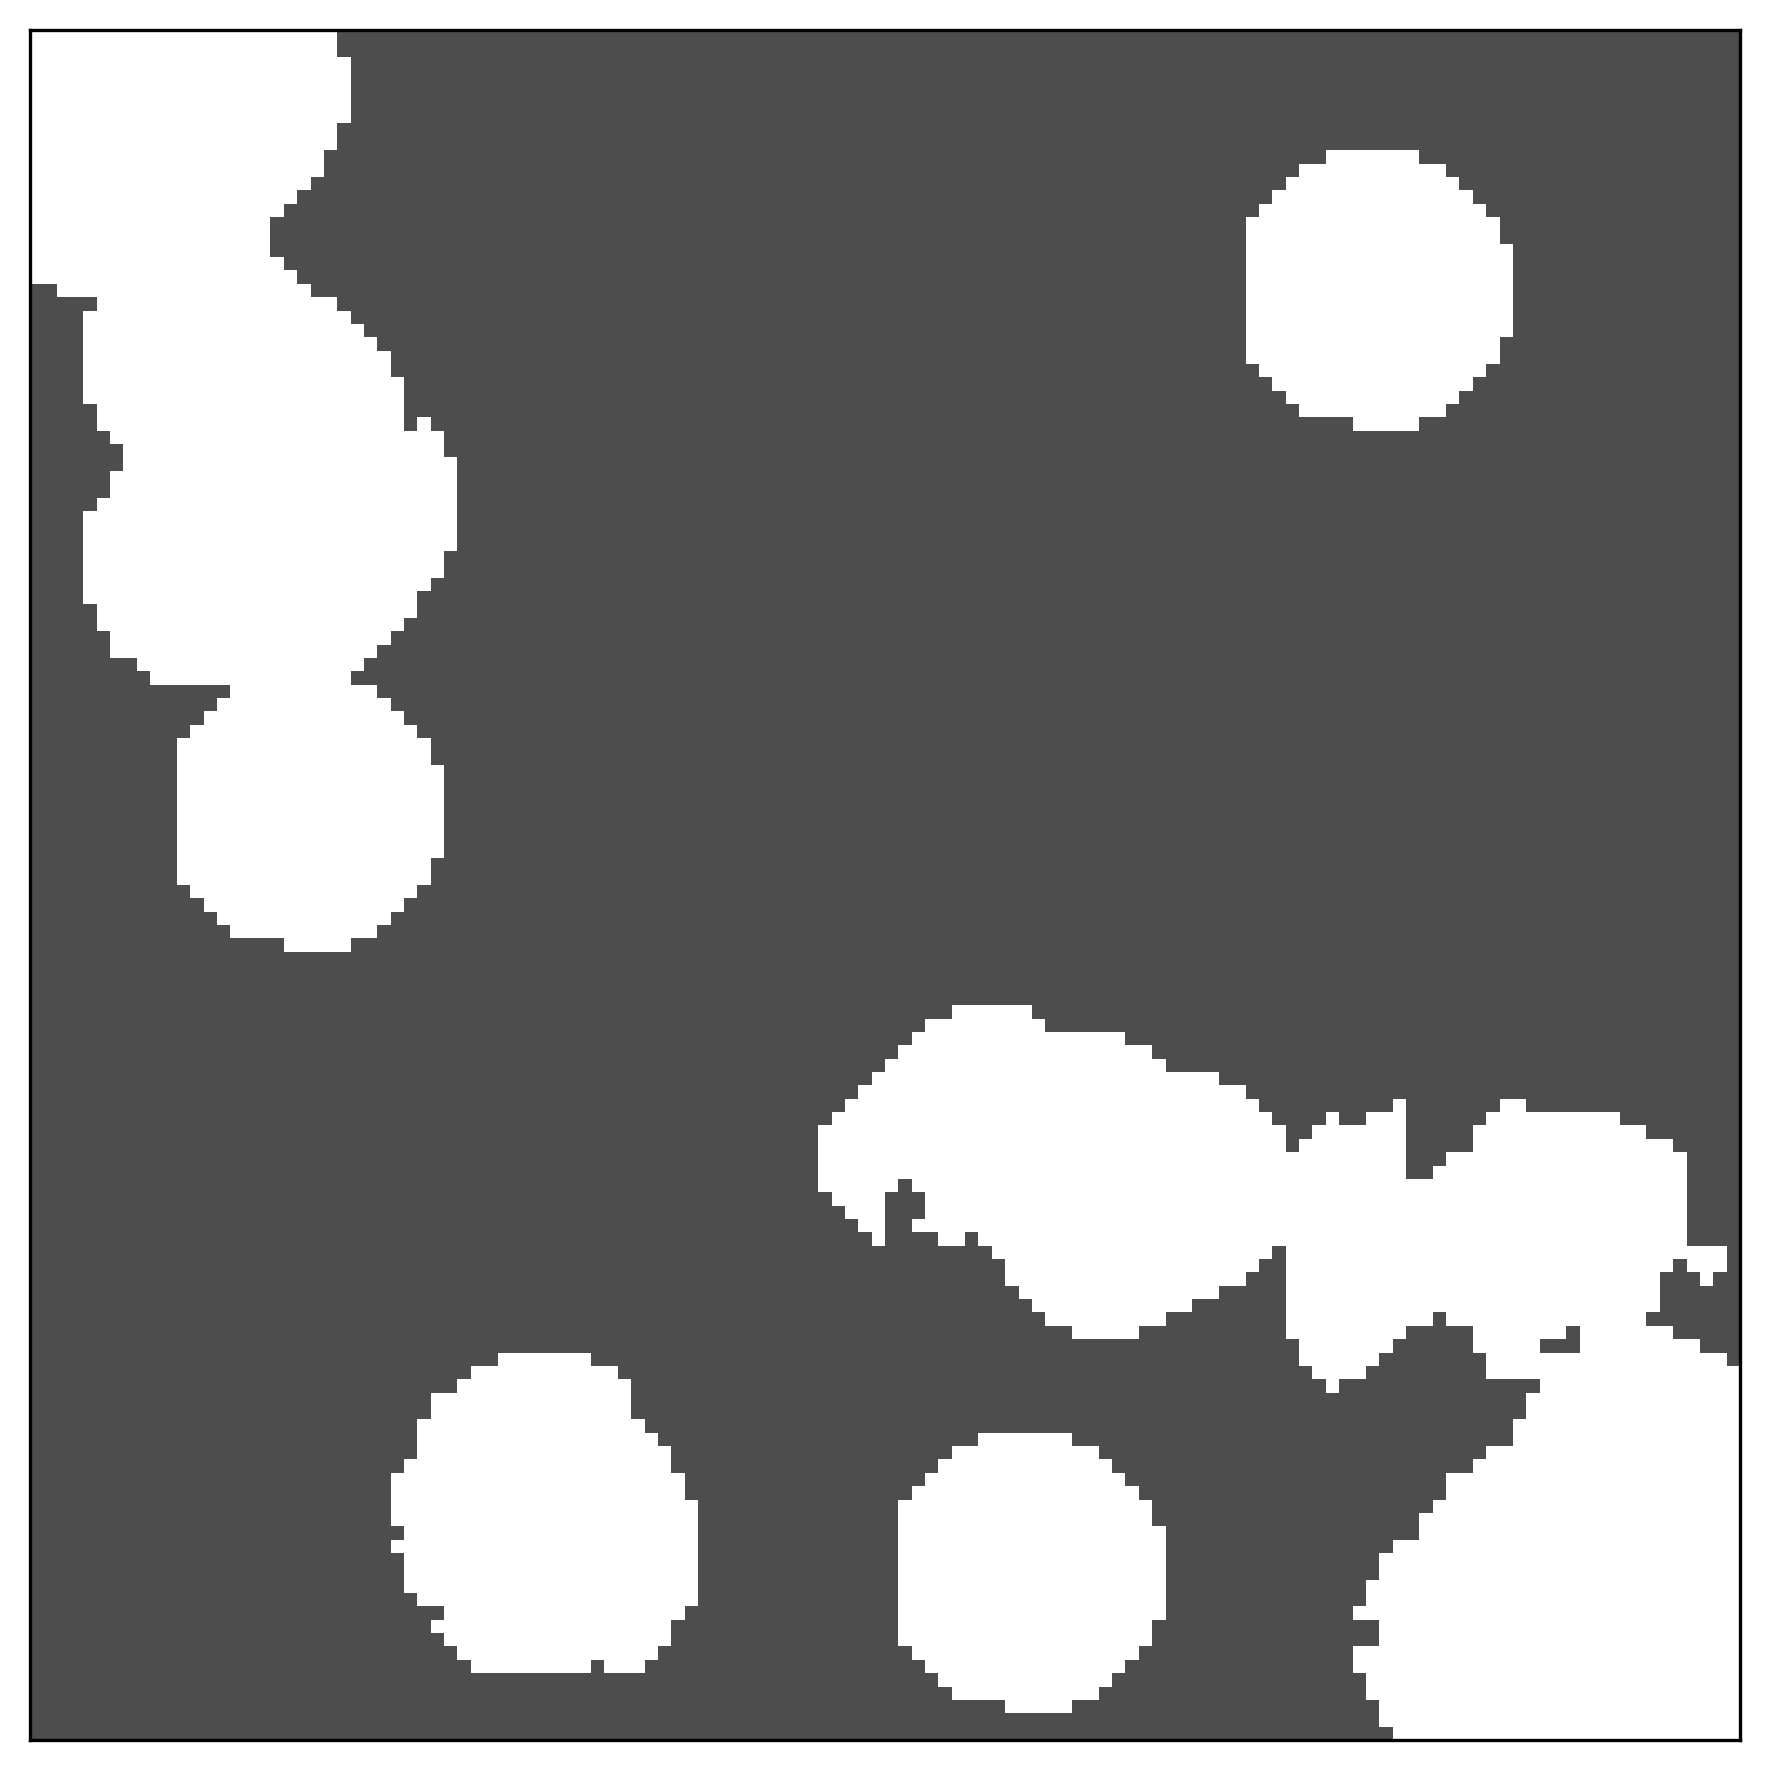

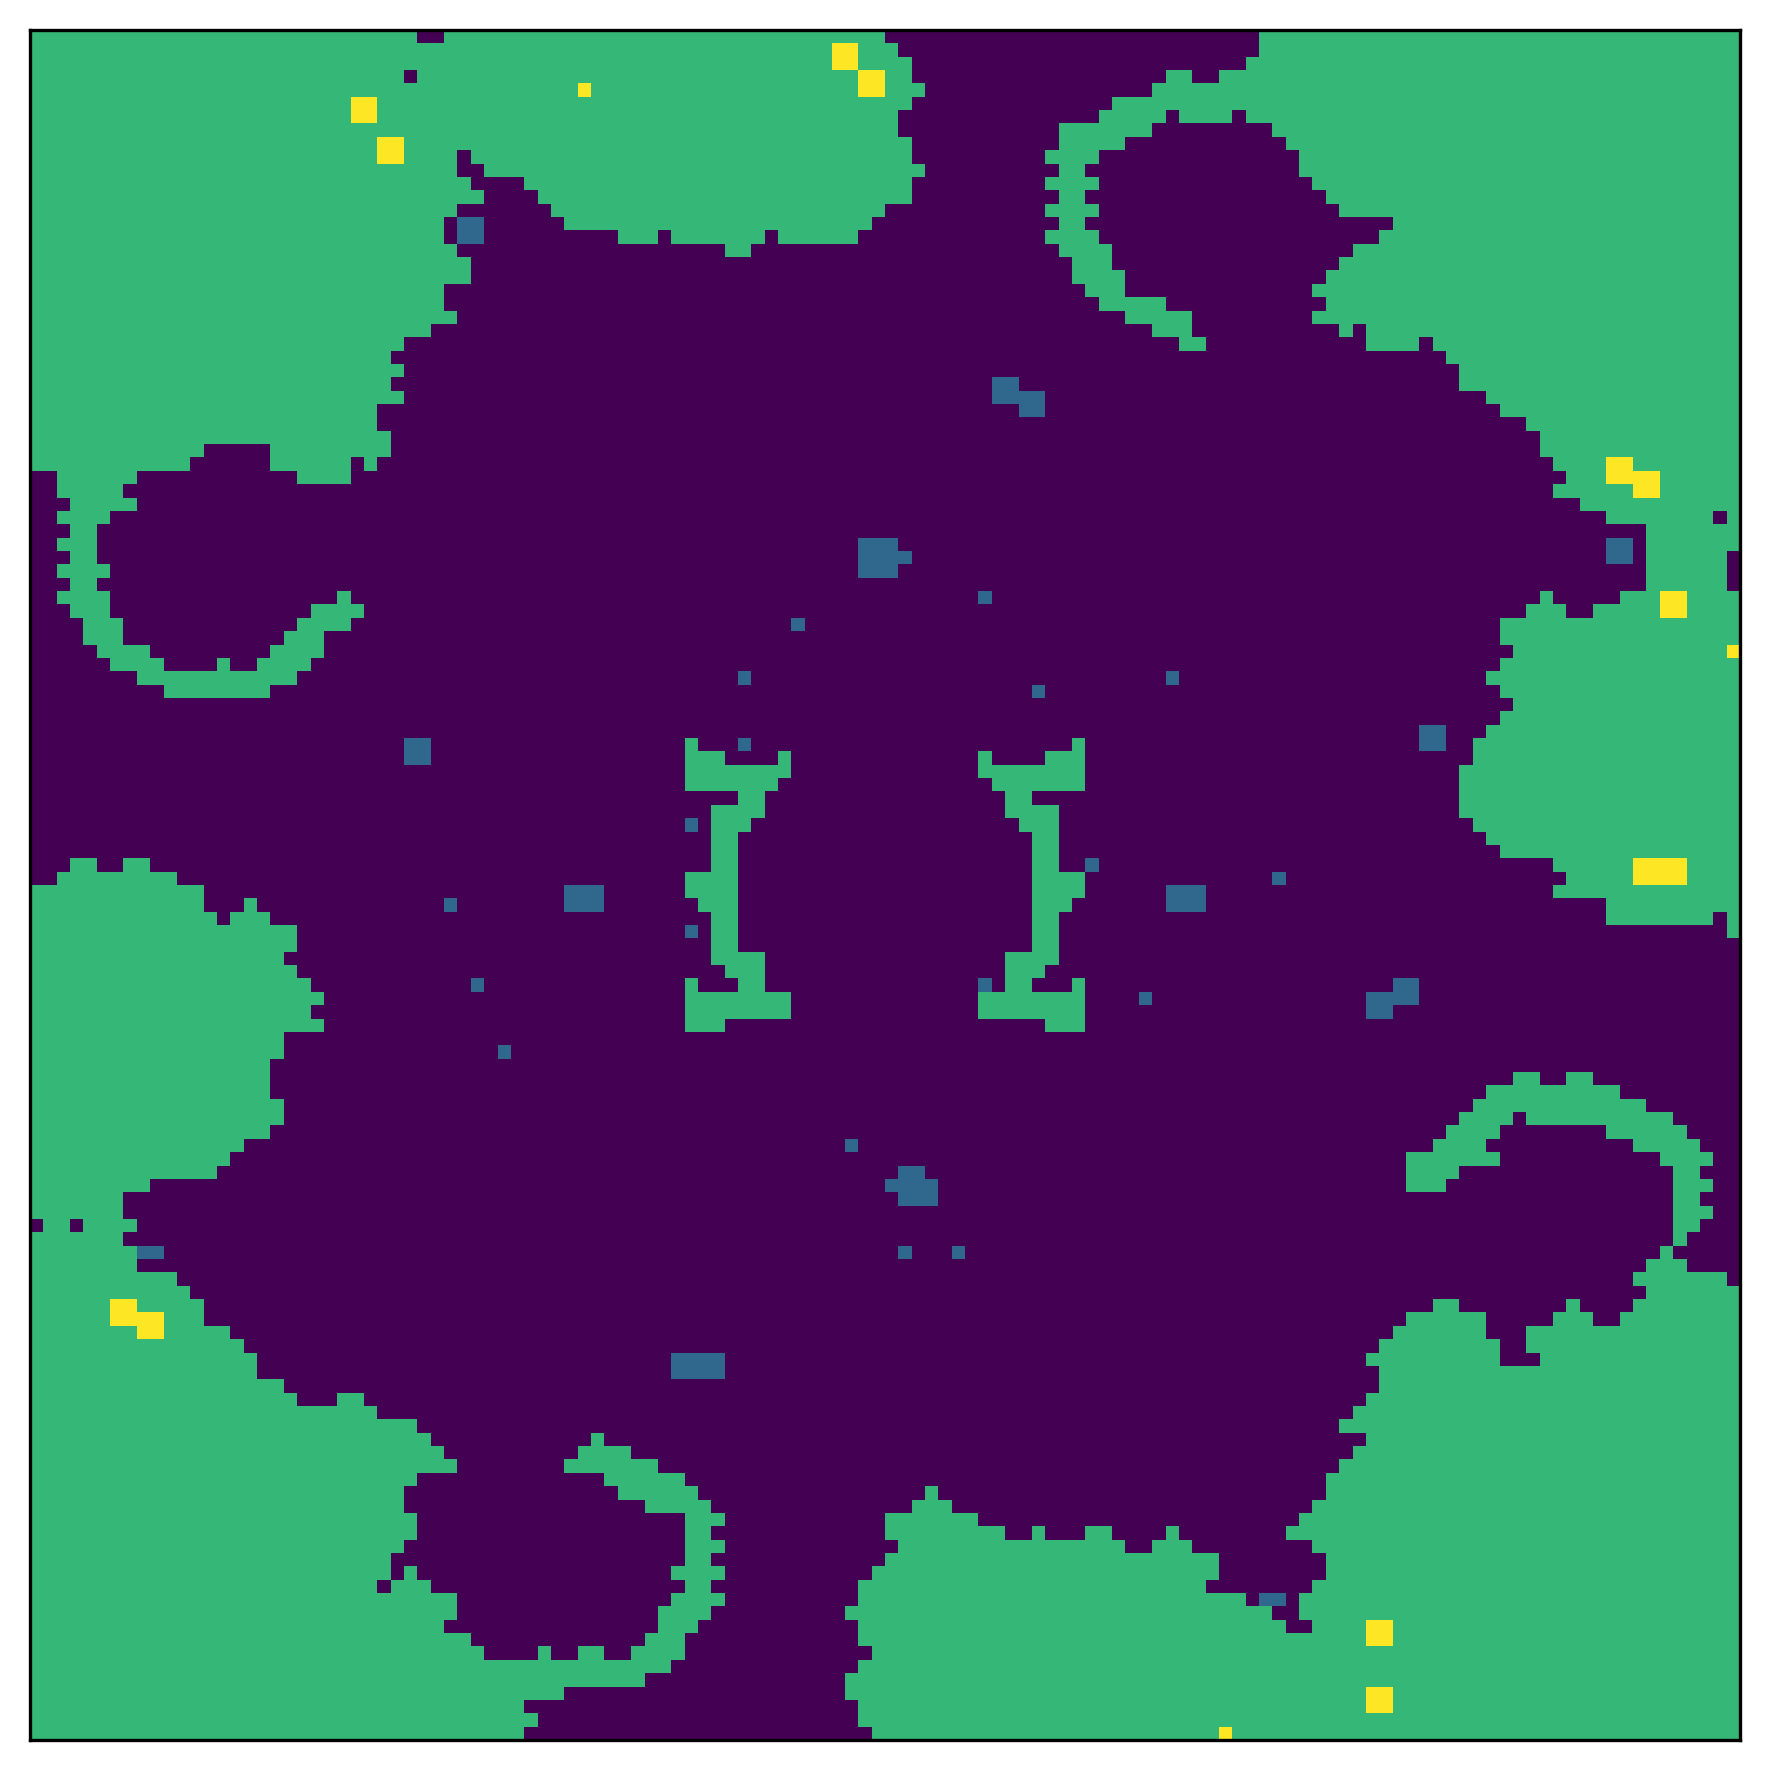

In [104]:
draw_channel(data, rep_name, frame)

In [ ]:
draw_overview(data, rep_name, frame)

In [106]:
vision_raw = data[Channel.Vision.value]

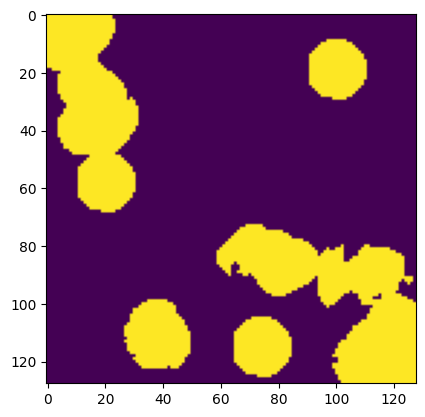

In [107]:
plt.imshow(vision_raw)